In [52]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
import os,sys
from pathlib import Path

# NOTE: My .py files
from standardizing_data import (
    standardize_lc,normalize_standardized_lc,_apply_quality_mask,
    get_tess_lc,
    _get_colors,
    collect_lightcurves_for_target,
    # constants
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH
)


from phasefold import phasefold, plot_phasefolded
from astropy.stats import sigma_clip

# Read in catalog data

In [2]:
catalog_dir = (Path.cwd() / "../Catalog/").resolve()

nearby_TOI_MD_df=pd.read_csv(f'{catalog_dir}/nearby_TOI_MDs.csv')
nearby_TOI_MD_df.head(5)

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
0,0,spoc-s01-s36-b0A-CPKP,SPOC,410153553,136.01,PC,340.492100,-69.169000,340.496204,-69.172108,11.877,0.064,1325.724661,0.000156,0.462931,3.872269e-06,0.631015,0.022202,4677.673602,171.681260,"1,27,28,67,68,94,95,101,102,103,104",LHS 3844 b,5.09707,0.426694,1,0.188624,0.005710,1.517197,0.061800,723.372047,3043.0,63.0,64.709477,38.885654,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2020-10-27 13:01:47.547000+00:00,410153553,340.492156,-69.168978,334.3570,-726.9740,11.92380,STAR,tmgaia2,20190415,NaN,NaN,105-116381,22415815-6910089,NaN,NaN,6385548541499112448,33464847.0,NaN,tmgaia2,0.082820,0.086335,gaia2,67.15480,0.050599,gaia2,318.253844,-43.907555,304.887051,-54.122569,16.942,0.041,15.240,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.046,0.023,9.477,0.023,9.145,0.023,AAA-222-111-000-0-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3925,0.000738,0.007698,cdwrf,cdwrf,3004.0,157.0,5.08528,0.029186,NaN,NaN,0.188624,0.005710,0.157909,0.020067,23.52970,0.863072,DWARF,0.002610,0.000708,14.8846,0.0113,0.000000,0.000000,81.0,0.010833,NaN,NaN,0.009687,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,0.0113,bj2018,NaN,NaN,cdwrf,15.4512,0.007263,12.05170,0.002827,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.559812,1.338867,340.496204,-69.172108,0.041207,0.042399,1,0,0.0,0.1933,0.5347,1.570796,2.913518,8.243782,328.631928,NaN,8.866874e+07,64.915025,11.0,"3,3,3,2,2,2,2,4,4,3,3","2,1,2,2,1,2,1,3,2,3,2","0,0,0,0,0,0,0,0,0,0,0"
1,1,spoc-s01-s69-b0A-CP,SPOC/QLP,234994474,134.01,CP,350.031300,-60.065200,350.028592,-60.065729,9.169,0.019,1326.034032,0.000566,1.401518,4.810232e-06,1.158306,0.325507,593.754092,42.808456,"1,28,68,95,102,104,105",L 168-9 b,4.67812,0.063226,1,0.597007,0.018150,1.461685,1.838503,891.638989,3794.0,69.0,149.374754,20.450527,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-30 23:32:46.016000+00:00,234994474,350.031352,-60.065179,-319.9610,-127.7810,9.22978,STAR,tmgaia2,20190415,115211.0,9126-00748-1,150-224713,23200751-6003545,NaN,NaN,6491962296196145664,31785853.0,NaN,tmgaia2,0.102122,0.115073,gaia2,39.73310,0.037526,gaia2,321.954596,-53.560374,319.217901,-49.527946,12.460,0.025,11.005,0.018,Na

# Creating a workflow from existing tools

In [3]:
def timer(start,end,message):
    """
    Print the wall-clock runtime of a pipeline step in human-readable units.

    Automatically selects seconds, minutes, or hours based on the elapsed
    time so that log output is always legible regardless of step duration.
    Designed for inline use at the end of each named pipeline step.

    Parameters
    ----------
    start : float
        Start timestamp in seconds, as returned by ``time.time()``.
    end : float
        End timestamp in seconds, as returned by ``time.time()``.
    message : str
        Label printed before the runtime, e.g. ``'SAP took:'``.

    Returns
    -------
    None
        Prints to stdout; does not return a value.

    Notes
    -----
    Uses ``astropy.units`` for unit conversion.  Output format is:

        ``<message> <value> seconds|minutes|hours``

    The unit boundaries are: < 1 min → seconds; 1–60 min → minutes;
    ≥ 60 min → hours.

    Examples
    --------
    >>> import time
    >>> t0 = time.time()
    >>> # ... some computation ...
    >>> timer(t0, time.time(), 'SAP took:')
    SAP took: 4.231 seconds
    """
    import astropy.units as u
    runtime = (end-start)*u.second
    if runtime.to(u.minute) < 1*u.minute:
        print(message, np.round(runtime.value,3),'seconds \n')
    if (runtime.to(u.minute) >= 1*u.minute) & (runtime.to(u.minute) < 60*u.minute):
        print(message, np.round((runtime.to(u.minute)).value,3),'minutes \n')        
    if (runtime.to(u.minute) >= 60*u.minute):
        print(message, np.round((runtime.to(u.hour)).value,3),'hours \n')                


def target_to_lightcurve_workflow_V1(target, pipelines, target_Sector,
                                  DEFAULT_RADIUS, 
                                  DEFAULT_CADENCE, 
                                  DEFAULT_DOWNLOADPATH):
    import time as clock
    t_start = clock.time()
    
    ID = target['TIC ID'].item()
    target_P= target['Orbital Period (days) Value'].item()
    target_T0= target['Orbital Epoch Value'].item()
    target_Dep = target['Transit Depth Value'].item()/1e6
    target_Dur = target['Transit Duration (hours) Value'].item()
    if target_Sector is None:
        try:
            target_Sector = np.min(list(map(int, target['Sectors'].to_list()[0].split(',')))) #choosing 1st sector
        except AttributeError:
            target_Sector = np.min(list(map(int, target['Sectors'].split(',')))) #choosing 1st sector
    
    
    sector_results = collect_lightcurves_for_target(
    tic_id=ID,
    sector=target_Sector, 
    pipelines=pipelines,
    downloadpath=DEFAULT_DOWNLOADPATH,
    radius=DEFAULT_RADIUS,
    exptime=DEFAULT_CADENCE,
    apply_quality_mask=True,
    verbose=True
)
    
    # phasefolded comparison:
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    corrected_epochs = {}

    epoch_btjd = target_T0
    period = target_P

    sector_all_flux_unclipped = []
    sector_all_flux_clipped = []

    for i in range(len(pipelines)):
        p = pipelines[i]
        info = sector_results[p]
        C = pipeline_colors[i]

        if info["status"] != "ok":
            #print(f"Skipping {p}: {info['error']}")
            corrected_epochs[p] = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]

        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            continue

        t_first = lc_to_plot["time"].min()

        flux = lc_to_plot["flux_corr"].to_numpy()
        n_first = int(np.ceil((t_first - epoch_btjd) / period))
        # NOTE: the nearrest predicted transit
        corrected_epochs[p] = epoch_btjd + n_first * period
        flux_norm = flux / np.nanmedian(flux)

        clipped = sigma_clip(flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5)
        good = ~clipped.mask
        lc_clean = lc_to_plot.iloc[good]

        n_total = len(flux_norm)
        print(f"{p}: total {n_total} points")
        n_removed = np.sum(clipped.mask)
        print(f"{p}: removed {n_removed} points")

        plot_phasefolded(
            ax=axes[0],
            target=target,
            lc=lc_to_plot,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        plot_phasefolded(
            ax=axes[1],
            target=target,
            lc=lc_clean,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    if len(sector_all_flux_unclipped) > 0:
        all_flux_unclipped = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux_unclipped, 0.5),
            np.nanpercentile(all_flux_unclipped, 99.5)
        )

    if len(sector_all_flux_clipped) > 0:
        all_flux_clipped = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux_clipped, 0.5),
            np.nanpercentile(all_flux_clipped, 99.5)
        )

    for ax in axes:
        #ax.set_xlim(-3, 3)
        #ax.set_xlabel(f"Orbital Phase [Hours since {np.round(target['Orbital Epoch Value'].item(), 4)} BTJD]")
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")

    plt.tight_layout()
    plt.show()
    
    print(' ')
    print('================================')
    timer(t_start, clock.time(), "target_to_lightcurve_workflow function took:")
    print(' ')
    print('================================')
    return sector_results
    

In [4]:
#TOI-270 c (~5.66 d period, 2.4 Earth radii planet)
target = nearby_TOI_MD_df.loc[nearby_TOI_MD_df['TIC ID'].astype(int)==259377017].reset_index(drop=True).iloc[0]



pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
pipeline_colors = _get_colors(len(pipelines))

[collect] TESSSearch TIC 259377017, sector 3, exptime='30 minute'  (1 query for 4 pipelines)
  [QLP] downloading ...
Selected product row:
  target_name pipeline mission  sector  exptime  distance  year description
0   259377017      QLP    HLSP       3   1800.0       0.0  2018        FITS
choose_first_timeseries=True; sorted using: t_min
  [TESS-SPOC] downloading ...
Selected product row:
  target_name   pipeline mission  sector  exptime  distance  year description
0   259377017  TESS-SPOC    HLSP       3   1800.0       0.0  2018        FITS
choose_first_timeseries=True; sorted using: t_min
  [TGLC] downloading ...
Selected product row:
  target_name pipeline mission  sector  exptime  distance  year description
0   259377017     TGLC    HLSP       3   1800.0   0.60232  2018        FITS
choose_first_timeseries=True; sorted using: t_min
  [GSFC-ELEANOR-LITE] downloading ...
Selected product row:
  target_name           pipeline mission  sector  exptime  distance  year  \
0   259377017  

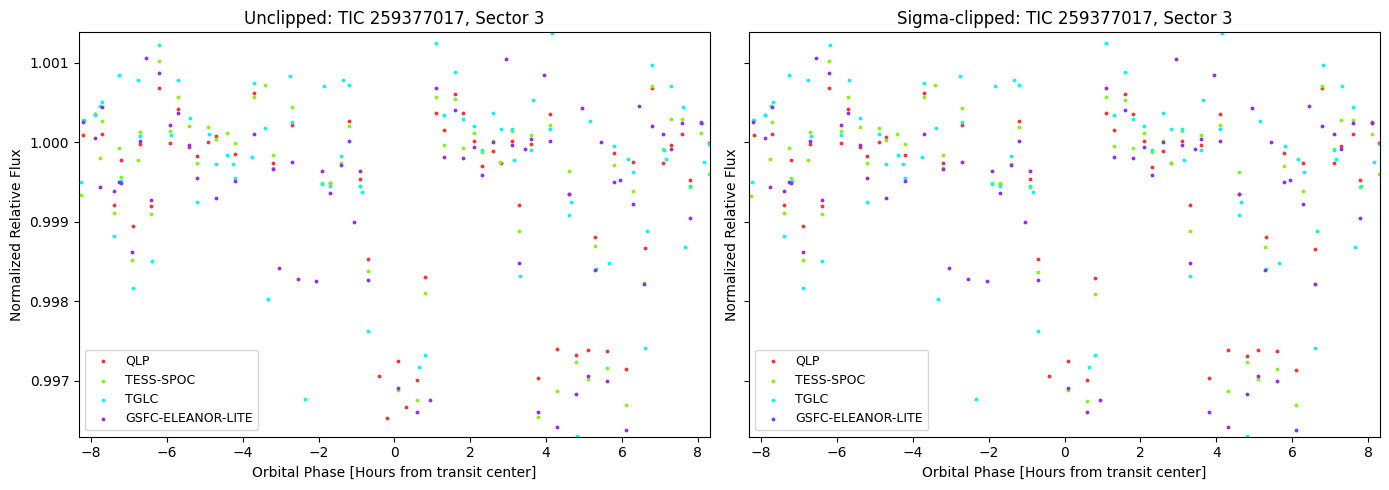

 
target_to_lightcurve_workflow function took: 26.407 seconds 

 


In [5]:
sector_results = target_to_lightcurve_workflow_V1(target=target, pipelines=pipelines, target_Sector=None,
                             DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
                             DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH)

In [6]:
print(type(sector_results),'\n')
print(sector_results.keys(),'\n')
print(sector_results['TGLC'].keys())

<class 'dict'> 

dict_keys(['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE']) 

dict_keys(['product', 'raw', 'standardized', 'standardized_masked', 'tic_id', 'sector', 'pipeline', 'n_raw', 'n_standardized', 'n_masked', 'status', 'error'])


# Dax's suggestions for patching helper functions in "standardizing_data.py"

# # Problem in get_tess_lc: 

The MAST search is always run (acceptable,  it's pretty fast), but product.download() re-fetches the FITS even if it already exists locally. The fix is a JSON cache index mapping a unique product key → local path, checked between search selection and download.

In [7]:
"""
Drop-in additions/replacements for standardizing_data.py.

Changes vs. original
--------------------
1. _load_fits_cache / _update_fits_cache  — JSON-backed FITS path index
2. get_tess_lc                            — full replacement; adds use_cache kwarg
3. save_pipeline_results                  — persist collect_lightcurves_for_target
                                            output as Parquet + JSON metadata
4. load_pipeline_results                  — reload a saved results dict from disk

Requires: json (stdlib), same imports as standardizing_data.py
"""
from __future__ import annotations

import json
import os
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
import lksearch as lk

# ---------------------------------------------------------------------------
# Module-level constant
# ---------------------------------------------------------------------------
_CACHE_INDEX_FILENAME = "hlsp_fits_cache.json"


# ---------------------------------------------------------------------------
# 1.  Cache helpers
# ---------------------------------------------------------------------------

def _load_fits_cache(downloadpath: str) -> Dict[str, str]:
    """
    Load the local FITS cache index from ``{downloadpath}/hlsp_fits_cache.json``.

    Returns an empty dict if the file does not yet exist.

    Parameters
    ----------
    downloadpath : str
        Directory where HLSP files are (or will be) stored.

    Returns
    -------
    index : dict
        Mapping of cache_key (str) -> absolute local file path (str).

    Examples
    --------
    >>> idx = _load_fits_cache("/data/HLSP")
    >>> idx.get("259377017__QLP__3__30_minute")
    '/data/HLSP/mastDownload/HLSP/.../file.fits'
    """
    index_path = os.path.join(downloadpath, _CACHE_INDEX_FILENAME)
    if os.path.exists(index_path):
        with open(index_path, "r") as fh:
            return json.load(fh)
    return {}


def _update_fits_cache(downloadpath: str, key: str, local_path: str) -> None:
    """
    Add or update one entry in the FITS cache index and write it to disk.

    Parameters
    ----------
    downloadpath : str
        Directory where the cache index lives.
    key : str
        Cache key for this product (see ``_build_fits_cache_key``).
    local_path : str
        Absolute path to the downloaded FITS file.

    Examples
    --------
    >>> _update_fits_cache("/data/HLSP", "259377017__QLP__3__30_minute",
    ...                    "/data/HLSP/mastDownload/HLSP/qlp.fits")
    """
    os.makedirs(downloadpath, exist_ok=True)
    index = _load_fits_cache(downloadpath)
    index[key] = local_path
    index_path = os.path.join(downloadpath, _CACHE_INDEX_FILENAME)
    with open(index_path, "w") as fh:
        json.dump(index, fh, indent=2)


def _build_fits_cache_key(
    best_tbl: pd.DataFrame,
    tic_str: str,
    pipeline: str,
    exptime: str,
) -> str:
    """
    Build a deterministic cache key for a single HLSP product.

    Strategy (priority order):
    1. Use ``dataURI`` / ``obs_id`` / ``productFilename`` from the product table
       — these are MAST-assigned unique identifiers.
    2. Fall back to ``(tic_str, pipeline, sector, exptime)`` constructed from
       the selected product row.

    Parameters
    ----------
    best_tbl : pd.DataFrame
        Single-row product table as selected inside ``get_tess_lc``.
    tic_str : str
        Normalised TIC identifier string (no leading zeros or ".0").
    pipeline : str
        HLSP pipeline name.
    exptime : str
        Cadence/exposure-time string (e.g. ``"30 minute"``).

    Returns
    -------
    key : str
        Cache key string safe for use as a JSON dict key.

    Examples
    --------
    >>> key = _build_fits_cache_key(best_tbl, "259377017", "QLP", "30 minute")
    >>> key
    '259377017__QLP__3__30_minute'
    """
    # Attempt to derive key from MAST product-level identifiers first
    for uri_col in ("dataURI", "dataurl", "obs_id", "obsid", "productFilename"):
        for col in best_tbl.columns:
            if col.lower().replace("_", "") == uri_col.lower().replace("_", ""):
                val = str(best_tbl[col].iloc[0]).strip()
                if val and val.lower() not in {"nan", "none", ""}:
                    # Sanitise for use as a JSON key (no path separators)
                    safe = val.replace("/", "__").replace("\\", "__")
                    return safe

    # Fallback: construct from (tic, pipeline, sector, exptime)
    sector_val = "None"
    for s_col in ("sector", "sequence_number", "year"):
        if s_col in best_tbl.columns:
            raw = str(best_tbl[s_col].iloc[0]).strip()
            if raw.lower() not in {"nan", "none", ""}:
                sector_val = raw
                break

    safe_exptime = exptime.replace(" ", "_")
    return f"{tic_str}__{pipeline}__{sector_val}__{safe_exptime}"


# ---------------------------------------------------------------------------
# 2.  get_tess_lc — full replacement with caching
# ---------------------------------------------------------------------------

def get_tess_lc(
    TIC_ID: Union[int, str],
    pipeline: str,
    radius: u.Quantity = DEFAULT_RADIUS,
    exptime: str = DEFAULT_CADENCE,
    Sector: Optional[Union[int, List[int]]] = None,
    downloadpath: str = DEFAULT_DOWNLOADPATH,
    *,
    verbose: bool = True,
    choose_first_timeseries: bool = True,
    use_cache: bool = True,
) -> Tuple[Any, pd.DataFrame, pd.DataFrame]:
    """
    Download one TESS HLSP light curve (FITS) via lksearch and return it
    as a pair of DataFrames (raw, standardized).  Previously downloaded
    products are served from a local JSON-backed cache — the FITS file is
    not re-fetched as long as it still exists on disk.

    Parameters
    ----------
    TIC_ID : int | str
        TIC identifier.
    pipeline : str
        HLSP pipeline name (e.g. ``"QLP"``, ``"TESS-SPOC"``).
    radius : astropy.units.Quantity
        Cone-search radius.
    exptime : str
        Exposure-time / cadence key (e.g. ``"30 minute"``).
    Sector : int | list[int] | None
        TESS sector(s) to filter on.
    downloadpath : str
        Directory where products are (or will be) stored.
    verbose : bool
        Print progress / selected-product summary.
    choose_first_timeseries : bool
        If True, prefer the earliest time-series product when multiple rows
        match.
    use_cache : bool
        If True (default), consult the local JSON cache before calling
        ``product.download()``.  Set to False to force a fresh download.

    Returns
    -------
    product : lksearch.TESSSearch
        Single-row TESSSearch object for the selected product.
    raw_df : pd.DataFrame
        Light-curve table read directly from the FITS BinTable extension.
    std_df : pd.DataFrame
        Standardized DataFrame via ``standardize_lc``.

    Raises
    ------
    ValueError
        If no matching HLSP timeseries product is found, or if the
        download manifest is empty.

    Notes
    -----
    Cache index is written to ``{downloadpath}/hlsp_fits_cache.json``.
    A cache entry is invalidated automatically if the recorded file path
    no longer exists on disk (stale entry).

    Examples
    --------
    >>> product, raw_df, std_df = get_tess_lc(259377017, "QLP", Sector=3)
    >>> product, raw_df, std_df = get_tess_lc(259377017, "QLP", Sector=3)
    # Second call reads from cache — no download.
    """
    import re  # local re import (already in stdlib)
    import lksearch as _lk

    os.makedirs(downloadpath, exist_ok=True)

    # --- Normalise TIC string ---
    tic_str = str(TIC_ID).strip()
    try:
        tic_str = str(int(float(tic_str)))
    except Exception:
        pass

    search_radius = (
        float(radius) if isinstance(radius, (int, float, np.floating)) else radius
    )

    # ------------------------------------------------------------------ #
    #  MAST search (always run — it is fast and determines which file     #
    #  to serve from cache).                                              #
    # ------------------------------------------------------------------ #
    search = _lk.TESSSearch(
        target=f"TIC {tic_str}",
        search_radius=search_radius,
        exptime=exptime,
        sector=Sector,
        hlsp=True,
    )
    try:
        ts = search.timeseries
    except Exception:
        ts = search

    filtered = ts.filter_table(mission="HLSP", pipeline=pipeline)

    if filtered.table is None or len(filtered.table) == 0:
        table = getattr(ts, "table", None)
        if isinstance(table, pd.DataFrame) and len(table) > 0:
            hlsp_tbl = (
                table[table["mission"].astype(str).eq("HLSP")]
                if "mission" in table.columns
                else table
            )
            avail = (
                np.unique(hlsp_tbl["pipeline"].astype(str))
                if "pipeline" in hlsp_tbl.columns and len(hlsp_tbl) > 0
                else np.array([])
            )
            raise ValueError(
                f"No HLSP timeseries product found for pipeline='{pipeline}' "
                f"(TIC={tic_str}, sector={Sector}, exptime={exptime}, "
                f"radius={radius}). Available HLSP pipelines: {avail.tolist()}"
            )
        raise ValueError(
            f"No products returned at all for TIC={tic_str}, sector={Sector}, "
            f"exptime={exptime}, radius={radius}."
        )

    tbl = filtered.table.copy()

    # ------------------------------------------------------------------ #
    #  Row selection (identical logic to original)                        #
    # ------------------------------------------------------------------ #
    sort_cols: List[str] = []
    time_col_used = None

    if choose_first_timeseries:
        for candidate in ["t_min", "tstart", "t_min_btjd", "start_time", "year"]:
            if candidate in tbl.columns:
                sort_cols.append(candidate)
                time_col_used = candidate
                break
        if "distance" in tbl.columns:
            sort_cols.append("distance")
        if not sort_cols and "description" in tbl.columns:
            sort_cols = ["description"]
        elif not sort_cols and "distance" in tbl.columns:
            sort_cols = ["distance"]
    else:
        if "distance" in tbl.columns:
            sort_cols = ["distance"]
        elif "t_min" in tbl.columns:
            sort_cols = ["t_min"]

    if sort_cols:
        tbl = tbl.sort_values(sort_cols, ascending=True).reset_index(drop=True)

    best_tbl = tbl.iloc[[0]].copy()
    import lksearch as _lk
    product = _lk.TESSSearch(table=best_tbl)

    if verbose:
        cols = [
            c for c in
            ["target_name", "pipeline", "mission", "sector", "exptime",
             "distance", "year", "description"]
            if c in best_tbl.columns
        ]
        print("Selected product row:")
        print(best_tbl[cols] if cols else best_tbl.head(1))
        if choose_first_timeseries:
            print(f"choose_first_timeseries=True; sorted using: {time_col_used}")

    # ------------------------------------------------------------------ #
    #  Cache lookup — skip download if FITS already on disk              #
    # ------------------------------------------------------------------ #
    cache_key = _build_fits_cache_key(best_tbl, tic_str, pipeline, exptime)
    local_path: Optional[str] = None

    if use_cache:
        cache_index = _load_fits_cache(downloadpath)
        cached_path = cache_index.get(cache_key)
        if cached_path and os.path.isfile(cached_path):
            if verbose:
                print(f"[cache hit]  {pipeline} TIC={tic_str} → {cached_path}")
            local_path = cached_path
        elif cached_path:
            if verbose:
                print(
                    f"[cache stale] recorded path no longer exists: {cached_path}\n"
                    f"              Re-downloading..."
                )

    # ------------------------------------------------------------------ #
    #  Download (only if no valid cached path found)                      #
    # ------------------------------------------------------------------ #
    if local_path is None:
        manifest = product.download(download_dir=downloadpath)

        if not isinstance(manifest, pd.DataFrame) or len(manifest) == 0:
            raise ValueError(
                "Download returned an empty manifest; nothing was downloaded."
            )

        path_col = None
        for c in manifest.columns:
            canon = c.lower().replace(" ", "").replace("_", "")
            if canon == "localpath":
                path_col = c
                break

        if path_col is None:
            raise ValueError(
                f"Could not find Local Path column in manifest. "
                f"Columns: {list(manifest.columns)}"
            )

        local_path = str(manifest[path_col].iloc[0])

        if use_cache:
            _update_fits_cache(downloadpath, cache_key, local_path)
            if verbose:
                print(f"[cache write] {cache_key} → {local_path}")

    # ------------------------------------------------------------------ #
    #  Read FITS → DataFrame → standardize                               #
    # ------------------------------------------------------------------ #
    with fits.open(local_path, memmap=False) as hdul:
        table_hdu = None
        for hdu in hdul[1:]:
            data = getattr(hdu, "data", None)
            if data is None:
                continue
            extname = str(getattr(hdu, "name", "")).upper()
            if hasattr(data, "names") and extname in {
                "LIGHTCURVE", "LIGHTCURVES", "LC", "TIME_SERIES", "TIMESERIES"
            }:
                table_hdu = hdu
                break
            if table_hdu is None and hasattr(data, "names"):
                table_hdu = hdu

        if table_hdu is None:
            raise ValueError(
                f"No table-like FITS extension found in file: {local_path}"
            )

        rec = np.array(table_hdu.data)
        if hasattr(rec.dtype, "isnative") and not rec.dtype.isnative:
            try:
                rec = rec.byteswap().newbyteorder()
            except AttributeError:
                rec = rec.byteswap().view(rec.dtype.newbyteorder("="))

        raw_df = pd.DataFrame.from_records(rec)
        std_df = standardize_lc(raw_df, pipeline)

    return product, raw_df, std_df


# ---------------------------------------------------------------------------
# 3.  Persist / reload results from collect_lightcurves_for_target
# ---------------------------------------------------------------------------

class _NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy scalar types from pandas/.item() calls."""
    def default(self, o: Any) -> Any:
        if isinstance(o, np.integer):
            return int(o)
        if isinstance(o, np.floating):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        return super().default(o)


def save_pipeline_results(
    results: Dict[str, Dict[str, Any]],
    savepath: str,
    tic_id: Union[int, str],
    sector: int,
    *,
    overwrite: bool = False,
) -> str:
    """
    Persist the output of ``collect_lightcurves_for_target`` to disk.

    Layout on disk::

        {savepath}/
          TIC{tic_id}_S{sector}/
            metadata.json                    ← status, errors, row counts
            {PIPELINE}_raw.parquet
            {PIPELINE}_standardized.parquet
            {PIPELINE}_standardized_masked.parquet

    Parquet is used for DataFrames (fast I/O, exact dtype preservation).
    ``None`` DataFrames (failed pipelines or disabled masking) are skipped
    silently — their absence is recorded in ``metadata.json``.

    Parameters
    ----------
    results : dict
        As returned by ``collect_lightcurves_for_target``.
    savepath : str
        Root directory under which the ``TIC{id}_S{sector}/`` folder is
        created.
    tic_id : int | str
        TIC identifier (used only for the folder name).
    sector : int
        Sector number (used only for the folder name).
    overwrite : bool
        If False (default) and the target directory already exists, raise
        FileExistsError.  If True, existing files are overwritten silently.

    Returns
    -------
    outdir : str
        Absolute path to the ``TIC{tic_id}_S{sector}/`` directory.

    Raises
    ------
    FileExistsError
        If the output directory already exists and ``overwrite=False``.

    Examples
    --------
    >>> outdir = save_pipeline_results(results, "/data/comparisons",
    ...                                tic_id=259377017, sector=3)
    >>> print(outdir)
    /data/comparisons/TIC259377017_S3
    """
    outdir = os.path.join(savepath, f"TIC{tic_id}_S{sector}")
    if os.path.exists(outdir) and not overwrite:
        raise FileExistsError(
            f"Output directory already exists: {outdir}\n"
            "Pass overwrite=True to replace existing files."
        )
    os.makedirs(outdir, exist_ok=True)

    metadata: Dict[str, Any] = {}

    for pipeline, info in results.items():
        meta_entry: Dict[str, Any] = {
            "tic_id": str(info.get("tic_id", tic_id)),
            "sector": info.get("sector", sector),
            "pipeline": pipeline,
            "status": info.get("status", "unknown"),
            "error": info.get("error"),
            "n_raw": info.get("n_raw"),
            "n_standardized": info.get("n_standardized"),
            "n_masked": info.get("n_masked"),
            "files": {},
        }

        for key in ("raw", "standardized", "standardized_masked"):
            df = info.get(key)
            if df is not None and not df.empty:
                fname = f"{pipeline}_{key}.parquet"
                fpath = os.path.join(outdir, fname)
                df.to_parquet(fpath, index=False)
                meta_entry["files"][key] = fname

        metadata[pipeline] = meta_entry

    meta_path = os.path.join(outdir, "metadata.json")
    with open(meta_path, "w") as fh:
        json.dump(metadata, fh, indent=2, cls=_NumpyEncoder)

    return outdir


def load_pipeline_results(
    savepath: str,
    tic_id: Union[int, str],
    sector: int,
) -> Dict[str, Dict[str, Any]]:
    """
    Reload a results dict previously saved by ``save_pipeline_results``.

    Reconstructs the same structure as ``collect_lightcurves_for_target``
    (minus the ``product`` field, which is not serialised).

    Parameters
    ----------
    savepath : str
        Root directory passed to ``save_pipeline_results``.
    tic_id : int | str
        TIC identifier.
    sector : int
        Sector number.

    Returns
    -------
    results : dict
        Keyed by pipeline name.  Each value has:
        ``raw``, ``standardized``, ``standardized_masked`` (DataFrames or
        None), plus all scalar metadata fields.  ``product`` is always None.

    Raises
    ------
    FileNotFoundError
        If the expected directory or ``metadata.json`` is missing.

    Examples
    --------
    >>> results = load_pipeline_results("/data/comparisons", 259377017, 3)
    >>> results["QLP"]["standardized"].head()
    """
    outdir = os.path.join(savepath, f"TIC{tic_id}_S{sector}")
    meta_path = os.path.join(outdir, "metadata.json")

    if not os.path.isdir(outdir):
        raise FileNotFoundError(f"Results directory not found: {outdir}")
    if not os.path.isfile(meta_path):
        raise FileNotFoundError(f"metadata.json not found in: {outdir}")

    try:
        with open(meta_path, "r") as fh:
            metadata = json.load(fh)
    except json.JSONDecodeError as exc:
        raise FileNotFoundError(
            f"metadata.json at {meta_path} is corrupt (truncated by a prior "
            f"failed write). Treating as cache miss. Original error: {exc}\n"
            f"The directory will be overwritten on next save."
        ) from exc

    results: Dict[str, Dict[str, Any]] = {}

    for pipeline, meta in metadata.items():
        entry: Dict[str, Any] = {
            "product": None,  # not serialised
            "raw": None,
            "standardized": None,
            "standardized_masked": None,
            "tic_id": meta.get("tic_id"),
            "sector": meta.get("sector"),
            "pipeline": pipeline,
            "n_raw": meta.get("n_raw"),
            "n_standardized": meta.get("n_standardized"),
            "n_masked": meta.get("n_masked"),
            "status": meta.get("status"),
            "error": meta.get("error"),
        }

        for key in ("raw", "standardized", "standardized_masked"):
            fname = meta.get("files", {}).get(key)
            if fname:
                fpath = os.path.join(outdir, fname)
                if os.path.isfile(fpath):
                    entry[key] = pd.read_parquet(fpath)

        results[pipeline] = entry

    return results

# New workflow with patched solutions above

In [8]:
def target_to_lightcurve_workflow_V2(
    target,
    pipelines,
    target_Sector,
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH,
    *,
    save_results: bool = True,
    results_savepath: str = None,
    force_redownload: bool = False,
):
    """
    Phase-fold and compare TESS HLSP light curves across multiple pipelines
    for a single target, with disk-backed caching of both FITS files and
    standardized DataFrames.

    On first call for a given (TIC, sector) pair, the function downloads all
    requested pipelines via ``collect_lightcurves_for_target`` and optionally
    persists the standardized results to Parquet on disk.  On subsequent
    calls, it attempts to load results from disk — skipping all network I/O —
    and only falls back to a live download if the saved data are not found.

    Parameters
    ----------
    target : pd.Series or single-row pd.DataFrame
        Row from the nearby TOI / M-dwarf catalog.  Must contain:
        ``'TIC ID'``, ``'Orbital Period (days) Value'``,
        ``'Orbital Epoch Value'``, ``'Transit Depth Value'``,
        ``'Transit Duration (hours) Value'``, and ``'Sectors'``.
    pipelines : list of str
        Pipeline names to compare (e.g. ``["QLP", "TESS-SPOC", "TGLC",
        "GSFC-ELEANOR-LITE"]``).
    target_Sector : int or None
        TESS sector to use.  If None, the first (earliest) sector listed in
        ``target['Sectors']`` is selected automatically.
    DEFAULT_RADIUS : astropy.units.Quantity
        Cone-search radius passed to ``collect_lightcurves_for_target``.
    DEFAULT_CADENCE : str
        Cadence/exptime string passed to ``collect_lightcurves_for_target``.
    DEFAULT_DOWNLOADPATH : str
        Root directory for FITS downloads and the FITS cache index.
    save_results : bool, optional
        If True (default), persist standardized DataFrames to Parquet after a
        live download run.  Has no effect when results are loaded from disk.
    results_savepath : str or None, optional
        Root directory for saved Parquet results.  Defaults to
        ``DEFAULT_DOWNLOADPATH + "/saved_results"`` if not provided.
    force_redownload : bool, optional
        If True, skip the disk cache entirely and re-run
        ``collect_lightcurves_for_target`` from scratch.  Useful when the
        on-disk data are stale or a pipeline has been updated.

    Returns
    -------
    sector_results : dict
        The results dict as returned by ``collect_lightcurves_for_target``
        (or reconstructed from disk by ``load_pipeline_results``).

    Examples
    --------
    >>> target = nearby_TOI_MD_df.loc[
    ...     nearby_TOI_MD_df['TIC ID'].astype(int) == 259377017
    ... ].reset_index(drop=True).iloc[0]
    >>> pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
    >>> pipeline_colors = _get_colors(len(pipelines))
    >>> results = target_to_lightcurve_workflow(
    ...     target=target,
    ...     pipelines=pipelines,
    ...     target_Sector=None,
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS,
    ...     DEFAULT_CADENCE=DEFAULT_CADENCE,
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    """
    import time as clock
    t_start = clock.time()
    # ------------------------------------------------------------------ #
    #  Unpack target metadata                                             #
    # ------------------------------------------------------------------ #
    ID          = target['TIC ID'].item()
    target_P    = target['Orbital Period (days) Value'].item()
    target_T0   = target['Orbital Epoch Value'].item()
    target_Dep  = target['Transit Depth Value'].item() / 1e6
    target_Dur  = target['Transit Duration (hours) Value'].item()

    if target_Sector is None:
        try:
            target_Sector = np.min(
                list(map(int, target['Sectors'].to_list()[0].split(',')))
            )
        except AttributeError:
            target_Sector = np.min(
                list(map(int, target['Sectors'].split(',')))
            )

    if results_savepath is None:
        results_savepath = os.path.join(DEFAULT_DOWNLOADPATH, "saved_results")

    # ------------------------------------------------------------------ #
    #  Cache layer: try loading from disk first                           #
    # ------------------------------------------------------------------ #
    sector_results = None

    if not force_redownload:
        try:
            sector_results = load_pipeline_results(
                savepath=results_savepath,
                tic_id=ID,
                sector=target_Sector,
            )
            print(
                f"[cache hit] Loaded saved results for TIC {ID}, "
                f"sector {target_Sector} from {results_savepath}"
            )
        except FileNotFoundError:
            print(
                f"[cache miss] No saved results found for TIC {ID}, "
                f"sector {target_Sector} — running live download."
            )

    # ------------------------------------------------------------------ #
    #  Live download (first run, or force_redownload=True)               #
    # ------------------------------------------------------------------ #
    if sector_results is None:
        sector_results = collect_lightcurves_for_target(
            tic_id=ID,
            sector=target_Sector,
            pipelines=pipelines,
            downloadpath=DEFAULT_DOWNLOADPATH,
            radius=DEFAULT_RADIUS,
            exptime=DEFAULT_CADENCE,
            apply_quality_mask=True,
            verbose=True,
        )

        if save_results:
            try:
                outdir = save_pipeline_results(
                    results=sector_results,
                    savepath=results_savepath,
                    tic_id=ID,
                    sector=target_Sector,
                    overwrite=force_redownload,
                )
                print(f"[saved] Results written to {outdir}")
            except FileExistsError:
                # Results directory already exists and overwrite=False.
                # This branch is only reachable if save_results=True but
                # force_redownload=False and the saved dir exists without a
                # readable metadata.json (edge case: partial prior write).
                print(
                    "[warning] Could not save results — directory exists. "
                    "Pass force_redownload=True to overwrite."
                )

    # ------------------------------------------------------------------ #
    #  Phase-folded comparison plot                                       #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    corrected_epochs    = {}
    epoch_btjd          = target_T0
    period              = target_P
    sector_all_flux_unclipped = []
    sector_all_flux_clipped   = []

    for i, p in enumerate(pipelines):
        info = sector_results[p]
        C    = pipeline_colors[i]

        if info["status"] != "ok":
            corrected_epochs[p] = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]
        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            continue

        t_first  = lc_to_plot["time"].min()
        flux     = lc_to_plot["flux_corr"].to_numpy()
        n_first  = int(np.ceil((t_first - epoch_btjd) / period))
        corrected_epochs[p] = epoch_btjd + n_first * period

        flux_norm = flux / np.nanmedian(flux)
        clipped   = sigma_clip(
            flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5
        )
        good      = ~clipped.mask
        lc_clean  = lc_to_plot.iloc[good]

        n_total   = len(flux_norm)
        n_removed = np.sum(clipped.mask)
        print(f"{p}: total {n_total} points, removed {n_removed} via sigma-clip")

        plot_phasefolded(
            ax=axes[0], target=target, lc=lc_to_plot,
            color=C, label=p, T0=corrected_epochs[p],
        )
        plot_phasefolded(
            ax=axes[1], target=target, lc=lc_clean,
            color=C, label=p, T0=corrected_epochs[p],
        )

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    if sector_all_flux_unclipped:
        all_flux_unclipped = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux_unclipped, 1),
            np.nanpercentile(all_flux_unclipped, 99),
        )
    if sector_all_flux_clipped:
        all_flux_clipped = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux_clipped, 1),
            np.nanpercentile(all_flux_clipped, 99),
        )

    for ax in axes:
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")
    plt.tight_layout()
    plt.show()
    
    print(' ')
    print('================================')
    timer(t_start, clock.time(), "target_to_lightcurve_workflow function took:")
    print(' ')
    print('================================')
    
    return sector_results

In [9]:
DEFAULT_DOWNLOADPATH

'/Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/'

[cache hit] Loaded saved results for TIC 259377017, sector 3 from /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results
QLP: total 857 points, removed 2 via sigma-clip
TESS-SPOC: total 857 points, removed 24 via sigma-clip
TGLC: total 1077 points, removed 50 via sigma-clip
GSFC-ELEANOR-LITE: total 789 points, removed 2 via sigma-clip


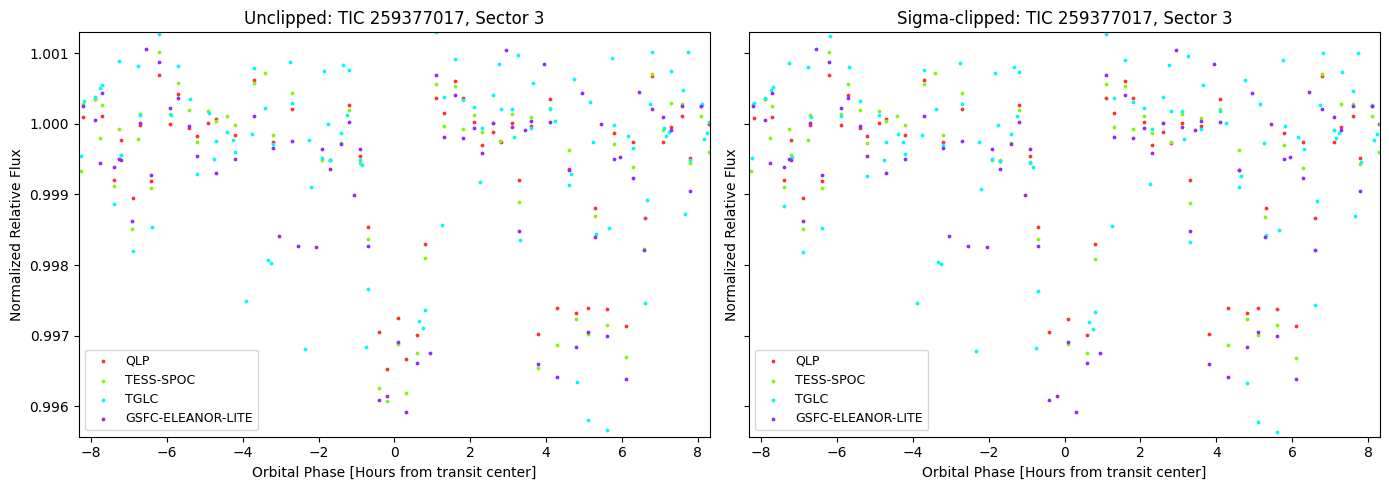

 
target_to_lightcurve_workflow function took: 0.231 seconds 

 


In [10]:
sector_results = target_to_lightcurve_workflow_V2(
    target=target, pipelines=pipelines, target_Sector=None,
    DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    save_results=True
)



In [11]:
print(sector_results.keys(),'\n')

print(sector_results['TGLC'].keys())

dict_keys(['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE']) 

dict_keys(['product', 'raw', 'standardized', 'standardized_masked', 'tic_id', 'sector', 'pipeline', 'n_raw', 'n_standardized', 'n_masked', 'status', 'error'])


# example of reading in .parquet file.


# Why .parquet? Parquet is a binary columnar file format,  think of it as a more efficient CSV that preserves column dtypes exactly (no float precision loss, no re-parsing strings as dates, etc.). It's from the data engineering world so it's less common in astronomy pipelines. Useful to know!

# JSON (JavaScript Object Notation) is just a structured text file,  you can open it in any text editor. In this context metadata.json only stores the scalar bookkeeping fields (status, n_raw, n_masked, error, etc.), not any flux data.

In [12]:
import pandas as pd

# Read any of the saved parquet files directly
df = pd.read_parquet("HLSP/saved_results/TIC259377017_S3/QLP_standardized.parquet")
print(df.head())
print(df.dtypes)
print(df.shape)
print('\n========================================\n')
print('\n========================================\n')
print('\n========================================\n')

# metadata.json is plain text — just read it
import json
with open("HLSP/saved_results/TIC259377017_S3/metadata.json") as f:
    print(json.dumps(json.load(f), indent=2))

          time  flux_raw  flux_raw_err  flux_corr  flux_corr_err   flux_bkg  \
0  1381.720593  1.000283           NaN   1.000523       0.000347 -43.166710   
1  1381.741427  0.999296           NaN   0.999452       0.000347 -44.053688   
2  1381.762261  1.001356           NaN   1.001439       0.000347 -52.293648   
3  1381.783095  1.000606           NaN   1.000622       0.000347 -52.649776   
4  1381.803928  0.999527           NaN   0.999484       0.000347 -51.260830   

   flux_bkg_err  quality  
0     11.372670     4096  
1      7.872932     4096  
2     11.884484     4096  
3     12.277895     4096  
4     10.927014     4096  
time             float64
flux_raw         float32
flux_raw_err     float64
flux_corr        float32
flux_corr_err    float32
flux_bkg         float32
flux_bkg_err     float32
quality            int32
dtype: object
(1304, 8)






{
  "QLP": {
    "tic_id": "259377017",
    "sector": 3,
    "pipeline": "QLP",
    "status": "ok",
    "error": null,
    "n_raw": 1

# Next up, we have to tack on LEO-Vetter into the workflow

# I needed to rework a lot of LEO-Vetter's functions to get the outputs as strings to place on a single figure. Below is a myriad of helper functions (from NEMESIS code) that does this.

In [13]:
# LEO VETTER STUFFZ (had to rework a lot of metric tests to output strings)
# reworked LEOvetter tools

def get_scalar(value):
    """
    Coerce any scalar-like object to a plain Python scalar.

    Handles the full variety of types that can appear in a LEO-Vetter
    metrics dictionary: Python native scalars, numpy scalars, 0-d numpy
    arrays, single-element numpy arrays, and single-element pandas Series.
    All FA/FP test functions call this before performing comparisons to
    avoid numpy/pandas type errors or ambiguous truth-value warnings.

    Parameters
    ----------
    value : scalar, np.ndarray, or pd.Series
        The value to coerce.  Must be a single element (not a multi-element
        array or Series).

    Returns
    -------
    scalar : int, float, bool, or str
        The plain Python scalar equivalent of ``value``.

    Raises
    ------
    ValueError
        If ``value`` is a multi-element array or Series.

    Examples
    --------
    >>> get_scalar(np.float64(3.14))
    3.14
    >>> get_scalar(pd.Series([7.0]))
    7.0
    >>> get_scalar(np.array([5]))
    5
    """
    # Already a Python scalar?
    if isinstance(value, (int, float, bool, str)):
        return value
    # Pandas scalar
    try:
        import pandas as pd
        if pd.api.types.is_scalar(value):
            return value
    except Exception:
        pass
    # NumPy scalar
    if hasattr(value, "item") and not isinstance(value, (list, tuple, dict)):
        try:
            return value.item()
        except Exception:
            pass
    # Numpy array / Pandas Series with single element
    if isinstance(value, (np.ndarray,)) or ("pandas" in str(type(value)) and hasattr(value, "size")):
        if getattr(value, "size", None) == 1:
            return value.item()
        raise ValueError("Expected a single value, but got multiple elements.")
    # Fallback: return as-is (assume scalar-like)
    return value


def format_conditions_block(header: str, lines: list[str], padding: int | float | str = 4) -> str:
    """
    Format a multi-line LEO-Vetter condition trace as an indented text block.

    The first condition line is appended directly after ``header``; all
    subsequent lines are indented by ``len(header) + padding`` spaces, so
    they align visually under the first line.  This replicates the padded
    layout used by the upstream ``leo_vetter.thresholds`` module.

    Parameters
    ----------
    header : str
        Label prefix, e.g. ``"weak: "``.  Its length determines the
        indentation of continuation lines.
    lines : list of str
        One string per condition sub-check.  ``lines[0]`` follows the
        header directly; ``lines[1:]`` are indented.
    padding : int, float, or str, optional
        Extra spaces added beyond ``len(header)`` for continuation lines.
        Coerced to ``int``; negative values are clamped to 0.
        Default is ``4``.

    Returns
    -------
    block : str
        Multi-line string with a trailing newline after each condition line.

    Examples
    --------
    >>> print(format_conditions_block("weak: ", ["MES: 4.2 >= 7.1"]))
    weak: MES: 4.2 >= 7.1

    >>> print(format_conditions_block(
    ...     "non_unique: ",
    ...     ["MS1: 3.1 >= 0.0", "MS2: 1.2 >= 0.0", "MS3: 0.8 < 0.0"],
    ...     padding=0))
    non_unique: MS1: 3.1 >= 0.0
                MS2: 1.2 >= 0.0
                MS3: 0.8 < 0.0
    """
    # Robustly coerce padding to an int (handles str, float, numpy/pandas scalars)
    try:
        pad = int(padding)
    except Exception:
        pad = 4  # safe default if something odd is passed

    if pad < 0:  # don't allow negative padding; clamp to zero
        pad = 0

    out = header
    for i, line in enumerate(lines):
        if i == 0:
            out += f"{line}\n"
        else:
            out += f"{' ' * (len(header) + pad)}{line}\n"
    return out

def weak(metrics, thresholds, pad: int = 4, float_round: int=2):
    """
    FA check: signal too weak (MES below minimum threshold).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = MES < thresholds["MES"]

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"MES"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"MES"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``4``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if MES is below the minimum threshold.
    message : str
        Human-readable label: ``"weak"``.
    output_string : str
        Formatted trace string showing the MES value and threshold.

    Notes
    -----
    NaN MES is treated as non-flagging (returns ``False``), consistent
    with upstream LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = weak(metrics, thresholds)
    >>> print(flag, msg)
    True weak
    """
    message = "FA: signal too weak"  # match thresholds.py message exactly

    # Robust scalar extraction (handles Series/ndarray/scalars uniformly)
    MES = get_scalar(metrics["MES"])
    thr = get_scalar(thresholds["MES"])

    # Flag condition identical to thresholds.py
    flag = bool(MES < thr)  # np.nan < thr -> False, matching source behavior

    # Compact, unambiguous trace    
    line = (f"MES: {np.round(MES,4)} < {np.round(thr,4)}"
            if flag else f"MES: {np.round(MES,4)} >= {np.round(thr,4)}")
    output_string = format_conditions_block(header="weak: ", lines=[line], padding=pad)
    return flag, message, output_string

def invalid_transits(metrics, thresholds, pad: int = 0, float_round: int=2):
    """
    FA check: insufficient valid transits after removing bad events.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (new_MES < thresholds["MES"]) or
               (new_N_transit < thresholds["N_transit"])

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"new_MES"``, ``"new_N_transit"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required keys: ``"MES"``, ``"N_transit"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``0``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the re-computed MES or transit count fall below thresholds.
    message : str
        Human-readable label: ``"invalid_transits"``.
    output_string : str
        Formatted trace string showing both sub-condition values and thresholds.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = invalid_transits(metrics, thresholds)
    """
    message = "FA: not enough valid transits"

    # Robust scalar extraction
    new_MES      = get_scalar(metrics["new_MES"])
    mes_thr      = get_scalar(thresholds["MES"])
    new_N_trans  = get_scalar(metrics["new_N_transit"])
    ntrans_thr   = get_scalar(thresholds["N_transit"])
    
    #get default N_transits setting

    # Exact predicates (NaN < x -> False, matching source semantics)
    mes_fail = bool(new_MES < mes_thr)
    ntr_fail = bool(new_N_trans < ntrans_thr)
    flag = mes_fail or ntr_fail

    # Render condition lines that mirror the predicates exactly
    lines = [
        (f"new_MES: {np.round(new_MES,4)} < {np.round(mes_thr, float_round)}"
         if mes_fail else
         f"new_MES: {np.round(new_MES,4)} >= {np.round(mes_thr, float_round)}"),
        (f"new_N_transit: {np.round(new_N_trans,4)} < {np.round(ntrans_thr, float_round)}"
         if ntr_fail else
         f"new_N_transit: {np.round(new_N_trans,4)} >= {np.round(ntrans_thr, float_round)}"),
    ]

    # Use your padding helper to build the block (original style)
    output_string = format_conditions_block(header="invalid_transits: ", lines=lines, padding=pad)

    return flag, message, output_string

def bad_shape(metrics, thresholds, pad: int=8 , float_round: int=2):
    """
    FA check: flux increases within the putative transit (bad transit shape).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = SHP > thresholds["SHP"]

    SHP = 0.0 indicates only flux decreases (transit-like);
    SHP = 0.5 indicates mixed;
    SHP = 1.0 indicates only flux increases (non-transit-like).

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"SHP"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"SHP"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if SHP exceeds the shape threshold.
    message : str
        Human-readable label: ``"bad_shape"``.
    output_string : str
        Formatted trace string showing the SHP value and threshold.

    Notes
    -----
    NaN SHP is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = bad_shape(metrics, thresholds)
    """
    message = "FA: bad transit shape"  # match thresholds.py exactly

    # Robust scalar extraction (works for scalars / 0-d arrays / 1-elt Series)
    SHP = get_scalar(metrics["SHP"])
    thr = get_scalar(thresholds["SHP"])

    # Exact predicate from thresholds.py
    flag = bool(SHP > thr)  # NaN > thr -> False, same semantics as source

    # Prepare the single condition line and format with your padding helper
    line = (f"SHP: {np.round(SHP, 4)} > {np.round(thr, float_round)}"
            if flag else
            f"SHP: {np.round(SHP, 4)} <= {np.round(thr, float_round)}")

    output_string = format_conditions_block(header="bad_shape: ", lines=[line], padding=pad)

    return flag, message, output_string

def non_unique(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FA check: events not unique in the phased light curve.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        MS1 = sig_pri / Fred - FA1
        MS2 = sig_pri - sig_ter - FA2
        MS3 = sig_pri - sig_pos - FA2

        flag = (MS1 < thresholds["MS1"]) or
               (MS2 < thresholds["MS2"]) or
               (MS3 < thresholds["MS3"])

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"sig_pri"``, ``"sig_ter"``, ``"sig_pos"``,
        ``"Fred"``, ``"FA1"``, ``"FA2"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required keys: ``"MS1"``, ``"MS2"``, ``"MS3"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if any of the three modshift sub-conditions fails.
    message : str
        Human-readable label: ``"non_unique"``.
    output_string : str
        Formatted trace string showing all three MS values and thresholds.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = non_unique(metrics, thresholds)
    """
    message = "FA: events not unique in phased light curve"

    # Pull scalars (robust to Series/ndarray/scalars)
    sig_pri = get_scalar(metrics["sig_pri"])
    sig_ter = get_scalar(metrics["sig_ter"])
    sig_pos = get_scalar(metrics["sig_pos"])
    Fred    = get_scalar(metrics["Fred"])
    FA1     = get_scalar(metrics["FA1"])
    FA2     = get_scalar(metrics["FA2"])

    MS1_thr = get_scalar(thresholds["MS1"])
    MS2_thr = get_scalar(thresholds["MS2"])
    MS3_thr = get_scalar(thresholds["MS3"])

    # Compute the scores with safety:
    # If Fred is non-positive or NaN, treat sig_pri/Fred as +inf so it cannot spuriously flag as "too small".
    if np.isfinite(Fred) and (Fred > 0):
        ms1 = (sig_pri / Fred) - FA1
    else:
        ms1 = np.inf

    ms2 = (sig_pri - sig_ter) - FA2
    ms3 = (sig_pri - sig_pos) - FA2

    # Predicates (exactly as in thresholds.py)
    p1 = bool(ms1 < MS1_thr)
    p2 = bool(ms2 < MS2_thr)
    p3 = bool(ms3 < MS3_thr)
    flag = p1 or p2 or p3

    # Render lines and format with your padding helper (restores your old alignment)
    def _fmt(x, float_round: int=2):  # stable numeric formatting incl. inf/nan
        return f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)

    lines = [
        (f"MS1: {_fmt(ms1)} < {_fmt(MS1_thr)}" if p1 else f"MS1: {_fmt(ms1)} >= {_fmt(MS1_thr)}"),
        (f"MS2: {_fmt(ms2)} < {_fmt(MS2_thr)}" if p2 else f"MS2: {_fmt(ms2)} >= {_fmt(MS2_thr)}"),
        (f"MS3: {_fmt(ms3)} < {_fmt(MS3_thr)}" if p3 else f"MS3: {_fmt(ms3)} >= {_fmt(MS3_thr)}"),
    ]

    output_string = format_conditions_block(header="non_unique: ", lines=lines, padding=pad)

    return flag, message, output_string

def chases(metrics, thresholds, pad: int = 5, float_round: int=2):
    """
    FA check: events not unique in the local light curve (few transits).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (N_transit <= 5) and (mean_chases < thresholds["chases"])

    This test is only active for TCEs with five or fewer observed transits,
    where the phased modshift statistics (non_unique) have low statistical
    power.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"N_transit"``, ``"mean_chases"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"chases"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``5``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the transit count is low and mean_chases fails the
        threshold.
    message : str
        Human-readable label: ``"chases"``.
    output_string : str
        Formatted trace string showing N_transit and mean_chases values.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = chases(metrics, thresholds)
    """
    message = "FA: events not unique in local light curve"

    # Robust scalars
    N_transit   = get_scalar(metrics["N_transit"])
    mean_chases = get_scalar(metrics["mean_chases"])
    ch_thr      = get_scalar(thresholds["chases"])

    # Exact predicates (NaNs do not flag: e.g., np.nan < ch_thr -> False)
    few_transits = bool(N_transit <= 5)
    low_chases   = bool(mean_chases < ch_thr)
    flag = few_transits and low_chases

    
    # Render predicate lines and format with your padding helper
    lines = [
        (f"N_transit: {np.round(N_transit, float_round)} <= 5"
         if few_transits else
         f"N_transit: {np.round(N_transit, float_round)} > 5"),
        (f"mean_chases: {np.round(mean_chases, float_round)} < {np.round(ch_thr, float_round)}"
         if low_chases else
         f"mean_chases: {np.round(mean_chases, float_round)} >= {np.round(ch_thr, float_round)}"),
    ]
    output_string = format_conditions_block(header="chases: ", lines=lines, padding=pad)

    return flag, message, output_string

def dmm(metrics, thresholds, pad: int = 4, float_round: int=2):
    """
    FA check: inconsistency between mean and median transit depths.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = DMM > thresholds["DMM"]

    A high DMM value indicates that a single anomalously deep event is
    driving the mean depth relative to the median, which is a signature
    of a noise spike or a systematic artefact rather than a periodic transit.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"DMM"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"DMM"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``4``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the depth mean/median ratio exceeds the threshold.
    message : str
        Human-readable label: ``"dmm"``.
    output_string : str
        Formatted trace string showing the DMM value and threshold.

    Notes
    -----
    NaN DMM is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = dmm(metrics, thresholds)
    """
    message = "FA: inconsistent transit depths"

    # Robust scalar extraction
    val = get_scalar(metrics["DMM"])
    thr = get_scalar(thresholds["DMM"])

    # Exact predicate; NaN/Inf should not trigger a flag
    flag = bool(np.isfinite(val) and np.isfinite(thr) and (val > thr))

    # Compact, faithful trace
    
    lhs = f"{np.round(val, float_round)}" if np.isfinite(val) else str(val)
    rhs = f"{np.round(thr, float_round)}" if np.isfinite(thr) else str(thr)
    line = f"{lhs} > {rhs}" if flag else f"{lhs} <= {rhs}"
    
    output_string = format_conditions_block("DMM: ", [line], padding=pad)

    return flag, message, output_string


def single_event(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FA check: signal dominated by a single event.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (sig_pri / Fred) < thresholds["MS1"] + FA1

    A low sig_pri/Fred ratio indicates that the primary event does not
    stand out above the noise floor scaled by the red-noise factor,
    suggesting the signal may originate from a single high-SNR noise
    excursion rather than a repeating transit.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"sig_pri"``, ``"Fred"``, ``"FA1"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"MS1"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the normalized primary event significance is below
        the single-event threshold.
    message : str
        Human-readable label: ``"single_event"``.
    output_string : str
        Formatted trace string showing the sig_pri/Fred ratio and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = single_event(metrics, thresholds)
    """
    message = "FA: dominated by single event"

    # Scalars
    max_SES    = get_scalar(metrics["max_SES"])
    MES        = get_scalar(metrics["MES"])
    N_transit  = get_scalar(metrics["N_transit"])
    thr        = get_scalar(thresholds["max_SES_to_MES"])

    # Compute ratio safely
    if np.isfinite(max_SES) and np.isfinite(MES) and (MES > 0):
        ratio = max_SES / MES
    else:
        # If MES<=0 or any is non-finite, treat as invalid ratio (won't flag)
        ratio = np.nan

    # Predicates (exactly as in thresholds.py)
    dom_single = bool(np.isfinite(ratio) and (ratio > thr))
    few_trans  = bool(np.isfinite(N_transit) and (N_transit <= 10))
    flag = dom_single and few_trans

    # Trace that mirrors predicates
    
    r_txt = f"{np.round(ratio, float_round)}" if np.isfinite(ratio) else str(ratio)
    t_txt = f"{np.round(thr, float_round)}" if np.isfinite(thr) else str(thr)
    
    lines = [
        (f"max_SES / MES: {r_txt} > {t_txt}" if dom_single
         else f"max_SES / MES: {r_txt} <= {t_txt}"),
        (f"N_transit: {np.round(N_transit, float_round)} <= 10" if few_trans
         else f"N_transit: {np.round(N_transit, float_round)} > 10"),
    ]
    output_string = format_conditions_block("single_event: ", lines, padding=pad)

    return flag, message, output_string

def bad_fit(metrics, thresholds, pad: int = 4, float_round: int=2):
    """
    FA check: poor fit of the trapezoidal transit model.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (sig_pri - Fred) < thresholds["bad_fit"]

    A small difference between the primary event significance and the
    red-noise factor indicates that the transit model does not improve
    significantly over a flat baseline, implying a poorly constrained or
    degenerate fit.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"sig_pri"``, ``"Fred"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"bad_fit"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``4``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the fit quality falls below the threshold.
    message : str
        Human-readable label: ``"bad_fit"``.
    output_string : str
        Formatted trace string showing sig_pri, Fred, and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = bad_fit(metrics, thresholds)
    """
    message = "FA: bad transit model fit"

    # --- scalars ---
    transit_aic   = get_scalar(metrics["transit_aic"])
    line_aic      = get_scalar(metrics["line_aic"])
    transit_chi2  = get_scalar(metrics["transit_chisqr"])
    line_chi2     = get_scalar(metrics["line_chisqr"])
    n_transit     = get_scalar(metrics["N_transit"])
    AIC1          = get_scalar(thresholds["AIC1"])
    AIC2          = get_scalar(thresholds["AIC2"])

    # --- component predicates (match source semantics) ---
    fit_failed  = bool(np.isnan(transit_aic))  # exactly as in thresholds.py

    # NaN comparisons here yield False -> safe default
    chisqr_fail = bool(transit_chi2 > line_chi2)

    # delta_aic: if either term is non-finite, treat as NaN so it won't trigger
    delta_aic = (transit_aic - line_aic) if (np.isfinite(transit_aic) and np.isfinite(line_aic)) else np.nan
    gen_fail  = bool(np.isfinite(delta_aic) and (delta_aic > AIC1))  # for N_transit <= 10
    sub_fail  = bool(np.isfinite(delta_aic) and (delta_aic > AIC2))  # for N_transit > 10
    aic_fail  = (gen_fail and (n_transit <= 10)) or (sub_fail and (n_transit > 10))

    flag = fit_failed or chisqr_fail or aic_fail

    # --- trace that mirrors the exact predicates ---
    f = lambda x: f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)

    lines = [
        f"transit_aic NaN check: {fit_failed}",
        (f"transit_chisqr: {f(transit_chi2)} > line_chisqr: {f(line_chi2)}"
         if chisqr_fail else
         f"transit_chisqr: {f(transit_chi2)} <= line_chisqr: {f(line_chi2)}"),
        (f"transit_aic - line_aic: {f(delta_aic)} > AIC1: {f(AIC1)}"
         if gen_fail else
         f"transit_aic - line_aic: {f(delta_aic)} <= AIC1: {f(AIC1)}"),
        (f"transit_aic - line_aic: {f(delta_aic)} > AIC2: {f(AIC2)}"
         if sub_fail else
         f"transit_aic - line_aic: {f(delta_aic)} <= AIC2: {f(AIC2)}"),
        (f"N_transit: {f(n_transit)} <= 10" if (n_transit <= 10)
         else f"N_transit: {f(n_transit)} > 10"),
    ]
    output_string = format_conditions_block("bad_fit: ", lines, padding=pad)

    return flag, message, output_string
#
#
def sinusoidal(metrics, thresholds, pad: int = 6, float_round: int=2):
    """
    FA check: signal consistent with sinusoidal variability.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = Fred > thresholds["Fred"]

    A high Fred (red-noise factor) means that correlated noise at the
    transit period dominates the phased LC, making the signal indistinguishable
    from stellar rotation, ellipsoidal variability, or other sinusoidal systematics.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"Fred"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"Fred"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``6``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the red-noise factor exceeds the sinusoidal threshold.
    message : str
        Human-readable label: ``"sinusoidal"``.
    output_string : str
        Formatted trace string showing the Fred value and threshold.

    Notes
    -----
    NaN Fred is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = sinusoidal(metrics, thresholds)
    """
    message = "FA: sinusoidal variations"

    # Robust scalar extraction
    sine_sig = get_scalar(metrics["sine_sig"])
    per      = get_scalar(metrics["per"])
    sweet    = get_scalar(thresholds["SWEET"])

    # Exact predicates; NaNs should not spuriously flag
    looks_sine = bool(np.isfinite(sine_sig) and np.isfinite(sweet) and (sine_sig > sweet))
    short_per  = bool(np.isfinite(per) and (per < 10))
    flag = looks_sine and short_per

    # Trace lines that mirror the predicates exactly
    def _fmt(x, float_round: int=2):  # stable formatting incl. nan/inf
        return f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)
    
    lines=[f"sine_sig: {_fmt(sine_sig)} > SWEET: {_fmt(sweet)}" if looks_sine \
            else f"sine_sig: {_fmt(sine_sig)} <= SWEET: {_fmt(sweet)}",
           f"per: {_fmt(per)} < 10" if short_per else f"per: {_fmt(per)} >= 10"]
    
    output_string = format_conditions_block("sinusoidal: ", lines, padding=pad)

    return flag, message, output_string

def unphysical_duration(metrics, thresholds, pad: int = 13, float_round: int=2):
    """
    FA check: transit duration is unphysically short or long.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (qtran < thresholds["qtran_lo"]) or
               (qtran > thresholds["qtran_hi"])

    ``qtran`` is the fractional transit duration (transit duration / period).
    Extremely short durations suggest a noise spike; extremely long durations
    are inconsistent with a Keplerian orbit at the fitted period.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"qtran"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required keys: ``"qtran_lo"``, ``"qtran_hi"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``13``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if qtran falls outside the physically plausible range.
    message : str
        Human-readable label: ``"unphysical_duration"``.
    output_string : str
        Formatted trace string showing qtran and both bounds.

    Notes
    -----
    NaN qtran is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = unphysical_duration(metrics, thresholds)
    """
    message = "FA: unphysical transit orbit"

    # --- robust scalars ---
    transit_aRs = get_scalar(metrics["transit_aRs"])
    aRs         = get_scalar(metrics["aRs"])
    q           = get_scalar(metrics["q"])
    trap_qtran  = get_scalar(metrics["trap_qtran"])
    sig_sec     = get_scalar(metrics["sig_sec"])

    # --- component predicates (exactly as in thresholds.py) ---
    # Division guard: if trap_qtran is nonpositive/NaN, treat q/trap_qtran as NaN -> won't trigger < 0.6
    if np.isfinite(q) and np.isfinite(trap_qtran) and (trap_qtran != 0):
        q_over_trap = q / trap_qtran
    else:
        q_over_trap = np.nan

    low_aRs = bool(
        (np.isfinite(transit_aRs) and (transit_aRs < 1.5)) or
        (np.isfinite(aRs) and (aRs < 2))
    )

    long_duration = bool(
        (np.isfinite(q_over_trap) and (q_over_trap < 0.6)) or
        np.isnan(sig_sec) or
        (np.isfinite(trap_qtran) and (trap_qtran > 0.5))
    )

    flag = low_aRs or long_duration

    # --- trace that mirrors predicates exactly ---
    def _fmt(x, float_round: int=2):
        return f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)

    f = lambda x: f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)
    lines = [
        (f"transit_aRs: {f(transit_aRs)} < 1.5 or aRs: {f(aRs)} < 2"
         if low_aRs else
         f"transit_aRs: {f(transit_aRs)} >= 1.5 & aRs: {f(aRs)} >= 2"),
        (f"q/trap_qtran: {f(q_over_trap)} < 0.6 or sig_sec is NaN or trap_qtran: {f(trap_qtran)} > 0.5"
         if long_duration else
         f"q/trap_qtran: {f(q_over_trap)} >= 0.6 and sig_sec not NaN & trap_qtran: {f(trap_qtran)} <= 0.5"),
    ]
    output_string = format_conditions_block("unphysical_duration: ", lines, padding=pad)
    return flag, message, output_string

def asymmetric(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FA check: left/right transit asymmetry.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        diff = |trap_qtran_L - trap_qtran_R|
        err  = sqrt(sigma_trap_qtran_L^2 + sigma_trap_qtran_R^2)
        flag = diff / err > thresholds["ASYM"]

    A significant difference between the ingress and egress durations of
    the best-fit trapezoidal model is inconsistent with a symmetric transit
    and may indicate a systematic artefact or an eclipsing binary.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"trap_qtran_left"``, ``"trap_qtran_right"``,
        ``"trap_qtran_err_left"``, ``"trap_qtran_err_right"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"ASYM"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the asymmetry significance exceeds the threshold.
    message : str
        Human-readable label: ``"asymmetric"``.
    output_string : str
        Formatted trace string showing diff/err and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = asymmetric(metrics, thresholds)
    """
    message = "FA: asymmetric events"

    # Robust scalar extraction
    qL   = get_scalar(metrics["trap_qtran_left"])
    qR   = get_scalar(metrics["trap_qtran_right"])
    eL   = get_scalar(metrics["trap_qtran_err_left"])
    eR   = get_scalar(metrics["trap_qtran_err_right"])
    asym = get_scalar(thresholds["ASYM"])

    # Compute diff and err safely
    diff = np.abs(qL - qR)

    # err = sqrt(eL^2 + eR^2), treat invalid (nan/inf/<=0) as non-flagging
    if np.isfinite(eL) and np.isfinite(eR):
        err = np.sqrt(eL**2 + eR**2)
        # Guard degenerate uncertainties
        if not np.isfinite(err) or err <= 0:
            ratio = np.nan
        else:
            ratio = diff / err
    else:
        err = np.nan
        ratio = np.nan

    # Exact predicate (as in thresholds.py)
    flag = bool(np.isfinite(ratio) and (ratio > asym))

    # Trace lines that mirror the predicate exactly
    def _fmt(x, float_round: int=2):
        return f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)

    
    sqrt_sym = u"\u221A"
    
    # --- format line like *_OLD (LaTeX-style, with two-decimal ratio) ---
    val_txt = f"{np.round(ratio, float_round)}" if np.isfinite(ratio) else str(ratio)
    line = (
        r"$\frac{(trap\ qtran_L - trap\ qtran_R)}{\sqrt{(\sigma_{trap\_qtran\_L}^{2} + \sigma_{trap\_qtran\_R}^{2})}}$ : "
        f"{val_txt} > {asym}"
        if flag
        else
        r"$\frac{(trap\ qtran_L - trap\ qtran_R)}{\sqrt{(\sigma_{trap\_qtran\_L}^{2} + \sigma_{trap\_qtran\_R}^{2})}}$ : "
        f"{val_txt} <= {asym}"
    )

    output_string = format_conditions_block("asymmetric: ", [line], padding=pad)
    return flag, message, output_string

def chi(metrics, thresholds, pad: int = 4, float_round: int=2):
    """
    FA check: inconsistent per-transit SNRs (χ² statistic).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = CHI < thresholds["CHI"]

    A low CHI value indicates that the per-transit depth estimates are
    mutually inconsistent at a level incompatible with photon noise,
    suggesting that the apparent periodicity arises from a subset of
    anomalous events rather than a true repeating signal.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"CHI"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"CHI"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``4``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the CHI statistic falls below the consistency threshold.
    message : str
        Human-readable label: ``"chi"``.
    output_string : str
        Formatted trace string showing the CHI value and threshold.

    Notes
    -----
    NaN CHI is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = chi(metrics, thresholds)
    """
    message = "FA: inconsistent transit SNRs"

    # Robust scalar extraction
    chi_val = get_scalar(metrics["CHI"])
    chi_thr = get_scalar(thresholds["CHI"])

    # Exact predicate; NaN/Inf should not trigger a flag
    flag = bool(np.isfinite(chi_val) and np.isfinite(chi_thr) and (chi_val < chi_thr))

    # Compact, faithful trace
    
    lhs = f"{np.round(chi_val, float_round)}" if np.isfinite(chi_val) else str(chi_val)
    rhs = f"{np.round(chi_thr, float_round)}" if np.isfinite(chi_thr) else str(chi_thr)
    line = f"{lhs} < {rhs}" if flag else f"{lhs} >= {rhs}"
    output_string = format_conditions_block("chi: ", [line], padding=pad)
    return flag, message, output_string

def data_gapped(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FA check: too many transits fall near data gaps.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        ratio = N_gap_2.0 / N_transit
        flag  = ratio >= thresholds["frac_gap"]

    A high fraction of transit windows that overlap data gaps reduces
    the effective number of clean transit observations and can produce
    spurious modshift statistics.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"N_gap_2.0"``, ``"N_transit"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"frac_gap"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the gapped-transit fraction meets or exceeds the threshold.
    message : str
        Human-readable label: ``"data_gapped"``.
    output_string : str
        Formatted trace string showing the ratio and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = data_gapped(metrics, thresholds)
    """
    message = "FA: too many transits near gaps"

    # --- scalars ---
    N_gap_2_0 = get_scalar(metrics["N_gap_2.0"])
    N_transit = get_scalar(metrics["N_transit"])
    frac_gap  = get_scalar(thresholds["frac_gap"])

    # --- compute ratio safely ---
    if np.isfinite(N_gap_2_0) and np.isfinite(N_transit) and (N_transit > 0):
        ratio = N_gap_2_0 / N_transit
    else:
        # Degenerate/undefined case: do not flag based on this test.
        ratio = 0.0

    # --- predicate (exactly as in thresholds.py) ---
    flag = bool(ratio >= frac_gap)

    # --- trace mirroring the predicate ---
    
    lhs = f"{np.round(ratio, float_round)}" if np.isfinite(ratio) else str(ratio)
    rhs = f"{np.round(frac_gap, float_round)}" if np.isfinite(frac_gap) else str(frac_gap)
    
    line = (f"N_gap_2.0 / N_transit: {lhs} >= {rhs}" if flag
            else f"N_gap_2.0 / N_transit: {lhs} < {rhs}")
    
    output_string = format_conditions_block("data_gapped: ", [line], padding=pad)
    
    return flag, message, output_string

def odd_even(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FP check: significant odd/even transit depth mismatch (EB signature).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        diff = |dep_odd - dep_even|
        err  = sqrt(sigma_dep_odd^2 + sigma_dep_even^2)
        flag = diff / err > thresholds["odd_even"]

    A statistically significant depth difference between alternating
    transits is the classic signature of a grazing or near-equal-mass
    eclipsing binary where primary and secondary eclipses are confused
    at half the true period.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"dep_odd"``, ``"dep_even"``,
        ``"sig_dep_odd"``, ``"sig_dep_even"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"odd_even"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the odd/even depth difference is statistically significant.
    message : str
        Human-readable label: ``"odd_even"``.
    output_string : str
        Formatted trace string showing diff/err and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = odd_even(metrics, thresholds)
    """
    message = "FP: odd-even transit differences"

    # Hard-coded per thresholds.py (not from thresholds dict)
    cuts = {
        "sig_dep":           3.0,
        "trap_sig_dep":      3.0,
        "trap_sig_epo":     10.0,
        "transit_sig_dep":   3.0,
        "transit_sig_epo":  10.0,
    }

    # Robust scalar extraction
    sig_dep          = get_scalar(metrics["sig_dep"])
    trap_sig_dep     = get_scalar(metrics["trap_sig_dep"])
    trap_sig_epo     = get_scalar(metrics["trap_sig_epo"])
    transit_sig_dep  = get_scalar(metrics["transit_sig_dep"])
    transit_sig_epo  = get_scalar(metrics["transit_sig_epo"])

    # Predicates (guard NaNs: NaN > cut -> False)
    box_dep_sigma     = bool(np.isfinite(sig_dep)          and (sig_dep          > cuts["sig_dep"]))
    trap_dep_sigma    = bool(np.isfinite(trap_sig_dep)     and (trap_sig_dep     > cuts["trap_sig_dep"]))
    trap_epo_sigma    = bool(np.isfinite(trap_sig_epo)     and (trap_sig_epo     > cuts["trap_sig_epo"]))
    transit_dep_sigma = bool(np.isfinite(transit_sig_dep)  and (transit_sig_dep  > cuts["transit_sig_dep"]))
    transit_epo_sigma = bool(np.isfinite(transit_sig_epo)  and (transit_sig_epo  > cuts["transit_sig_epo"]))

    flag = (box_dep_sigma and (trap_dep_sigma or transit_dep_sigma)) or (transit_epo_sigma or trap_epo_sigma)

    f = lambda x: f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)
    lines = [
        (f"sig_dep: {f(sig_dep)} > {cuts['sig_dep']}" if box_dep_sigma
         else f"sig_dep: {f(sig_dep)} <= {cuts['sig_dep']}"),
        (f"trap_sig_dep: {f(trap_sig_dep)} > {cuts['trap_sig_dep']}" if trap_dep_sigma
         else f"trap_sig_dep: {f(trap_sig_dep)} <= {cuts['trap_sig_dep']}"),
        (f"transit_sig_dep: {f(transit_sig_dep)} > {cuts['transit_sig_dep']}" if transit_dep_sigma
         else f"transit_sig_dep: {f(transit_sig_dep)} <= {cuts['transit_sig_dep']}"),
        (f"transit_sig_epo: {f(transit_sig_epo)} > {cuts['transit_sig_epo']}" if transit_epo_sigma
         else f"transit_sig_epo: {f(transit_sig_epo)} <= {cuts['transit_sig_epo']}"),
        (f"trap_sig_epo: {f(trap_sig_epo)} > {cuts['trap_sig_epo']}" if trap_epo_sigma
         else f"trap_sig_epo: {f(trap_sig_epo)} <= {cuts['trap_sig_epo']}"),
    ]
    output_string = format_conditions_block("odd_even: ", lines, padding=pad)
    return flag, message, output_string


def vshaped(metrics, thresholds, pad: int = 8, float_round: int=2):
    """
    FP check: V-shaped transit event (consistent with a grazing eclipsing binary).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = (transit_b + transit_RpRs) > thresholds["V_shape"]

    A high value of impact parameter b plus radius ratio Rp/Rs indicates a
    grazing geometry where the eclipse is V-shaped rather than flat-bottomed,
    consistent with a stellar eclipsing binary rather than a sub-stellar companion.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"transit_b"``, ``"transit_RpRs"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"V_shape"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``8``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if b + Rp/Rs exceeds the V-shape threshold.
    message : str
        Human-readable label: ``"vshaped"``.
    output_string : str
        Formatted trace string showing b + Rp/Rs and threshold.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = vshaped(metrics, thresholds)
    """
    message = "FP: V-shaped events"

    # Robust scalar extraction
    b     = get_scalar(metrics["transit_b"])
    rprs  = get_scalar(metrics["transit_RpRs"])
    vcut  = get_scalar(thresholds["V_shape"])

    # Compute sum safely (invalid -> no flag)
    if np.isfinite(b) and np.isfinite(rprs) and np.isfinite(vcut):
        s = b + rprs
        flag = bool(s > vcut)
    else:
        s = np.nan
        flag = False

    f = lambda x: f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)
    line = (f"transit_b + transit_RpRs: {f(s)} > {f(vcut)}"
            if flag else
            f"transit_b + transit_RpRs: {f(s)} <= {f(vcut)}")
    output_string = format_conditions_block("vshaped: ", [line], padding=pad)
    return flag, message, output_string

def large(metrics, thresholds, pad: int = 6, float_round: int=2):
    """
    FP check: planet candidate radius too large (likely an eclipsing binary).

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = Rp > thresholds["size"]

    Planet candidates with radii above the threshold are more consistent
    with stellar or brown-dwarf companions than with sub-Jovian or smaller
    planets, and are therefore flagged as likely false positives.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"Rp"`` (planet radius in Earth radii).
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"size"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``6``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the planet radius exceeds the size threshold.
    message : str
        Human-readable label: ``"large"``.
    output_string : str
        Formatted trace string showing the Rp value and threshold.

    Notes
    -----
    NaN Rp is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = large(metrics, thresholds)
    """
    message = "FP: radius too large"

    # Robust scalar extraction
    Rp   = get_scalar(metrics["Rp"])
    size = get_scalar(thresholds["size"])

    # Exact predicate; invalid numbers should not spuriously flag
    flag = bool(np.isfinite(Rp) and np.isfinite(size) and (Rp > size))

    # Trace that mirrors the predicate exactly
    
    lhs = f"{np.round(Rp,  float_round )}" if np.isfinite(Rp) else str(Rp)
    rhs = f"{np.round(size, float_round)}" if np.isfinite(size) else str(size)
    
    line = f"Rp: {lhs} > {rhs}" if flag else f"Rp: {lhs} <= {rhs}"
    output_string = format_conditions_block("large: ", [line], padding=pad)
    return flag, message, output_string

def secondary(metrics, thresholds, pad: int = 6, float_round: int=2):
    """
    FP check: significant secondary eclipse detected.

    Flag condition (composite; mirrors ``leo_vetter.thresholds.py``):

        MS4 = sig_sec / Fred - FA2 >= thresholds["MS2"]
        MS5 = sig_sec - sig_ter - FA2 >= thresholds["MS3"]
        MS6 = sig_sec - sig_pos - FA2 >= thresholds["MS3"]

        albedo_ok = (albedo < 1.0) and (dep_sec < 0.1 * dep)

        flag = (MS4 and (MS5 or MS6)) and (not albedo_ok)

    A detected secondary eclipse whose depth cannot be explained by a
    self-luminous reflection/thermal emission model (albedo ≥ 1 or
    secondary depth > 10 % of primary) indicates a background or
    bound eclipsing binary contaminating the aperture.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required keys: ``"sig_sec"``, ``"sig_ter"``, ``"sig_pos"``,
        ``"Fred"``, ``"FA2"``, ``"dep_sec"``, ``"dep"``, ``"Rp"``,
        ``"transit_b"``, ``"albedo"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required keys: ``"MS2"``, ``"MS3"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``6``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if a statistically significant, non-self-luminous secondary
        eclipse is detected.
    message : str
        Human-readable label: ``"secondary"``.
    output_string : str
        Formatted trace string showing all sub-condition values.

    Notes
    -----
    NaN inputs are treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = secondary(metrics, thresholds)
    """
    message = "FP: significant secondary"

    # --- pull scalars robustly ---
    sig_sec   = get_scalar(metrics["sig_sec"])
    sig_ter   = get_scalar(metrics["sig_ter"])
    sig_pos   = get_scalar(metrics["sig_pos"])
    Fred      = get_scalar(metrics["Fred"])
    FA1       = get_scalar(metrics["FA1"])
    FA2       = get_scalar(metrics["FA2"])

    MS4_thr   = get_scalar(thresholds["MS4"])
    MS5_thr   = get_scalar(thresholds["MS5"])
    MS6_thr   = get_scalar(thresholds["MS6"])

    # --- compute MS4 value safely (avoid divide-by-zero / invalid Fred) ---
    if np.isfinite(sig_sec) and np.isfinite(Fred) and (Fred != 0):
        MS4_val = (sig_sec / Fred) - FA1
    else:
        MS4_val = -np.inf  # ensures the comparison "MS4_val > MS4_thr" won't spuriously pass

    # --- MS5/MS6 values; if comparator term is NaN, keep value NaN (won't pass > threshold) ---
    MS5_val = (sig_sec - sig_ter) - FA2 if np.isfinite(sig_ter) else np.nan
    MS6_val = (sig_sec - sig_pos) - FA2 if np.isfinite(sig_pos) else np.nan

    # --- boolean predicates (exact thresholds.py behavior) ---
    MS4 = (np.isfinite(MS4_val) and (MS4_val > MS4_thr)) or (np.isfinite(Fred) and (Fred > 1.8))
    MS5 = (np.isfinite(MS5_val) and (MS5_val > MS5_thr)) or (not np.isfinite(sig_ter))
    MS6 = (np.isfinite(MS6_val) and (MS6_val > MS6_thr)) or (not np.isfinite(sig_pos))

    # --- "planet-consistent" allowance (albedo gate); only true if ALL checks are finite and satisfied ---
    Rp        = get_scalar(metrics["Rp"])
    size_thr  = get_scalar(thresholds["size"])
    albedo_v  = get_scalar(metrics["albedo"])
    dep_sec   = get_scalar(metrics["dep_sec"])
    dep       = get_scalar(metrics["dep"])
    transit_b = get_scalar(metrics["transit_b"])

    albedo_ok = (
        np.isfinite(Rp) and np.isfinite(size_thr) and (Rp < size_thr) and
        np.isfinite(albedo_v) and (albedo_v < 1.0) and
        np.isfinite(dep_sec) and np.isfinite(dep) and (dep > 0) and (dep_sec < 0.1 * dep) and
        np.isfinite(transit_b) and (transit_b < 0.95)
    )

    flag = (MS4 and (MS5 or MS6)) and (not albedo_ok)

    f = lambda x: f"{np.round(x, float_round)}" if np.isfinite(x) else str(x)
    
    lines = [
        (f"MS4: {f(MS4_val)} > {MS4_thr} or Fred>1.8" if MS4
         else f"MS4: {f(MS4_val)} <= {MS4_thr} & Fred<=1.8"),
        (f"MS5: {f(MS5_val)} > {MS5_thr} or sig_ter NaN" if MS5
         else f"MS5: {f(MS5_val)} <= {MS5_thr} & sig_ter not NaN"),
        (f"MS6: {f(MS6_val)} > {MS6_thr} or sig_pos NaN" if MS6
         else f"MS6: {f(MS6_val)} <= {MS6_thr} & sig_pos not NaN"),
        ("albedo TRUE: "
         if albedo_ok else
         "albedo FALSE: >=1 checks failed"),
    ]
    output_string = format_conditions_block("secondary: ", lines, padding=pad)
    return bool(flag), message, output_string

def offset(metrics, thresholds, pad: int = 4, float_round: int=2):
    """
    FP check: centroid offset indicates an off-target eclipsing binary.

    Flag condition (mirrors ``leo_vetter.thresholds.py``):

        flag = offset_qual > thresholds["offset"]

    A significant centroid shift phased to the transit period indicates
    that the photometric signal originates from a nearby star rather than
    the target, consistent with a background or bound eclipsing binary.

    This test is added to the sequence by ``check_ALL_thresholds`` only
    when ``'offset_qual'`` is present as a key in ``metrics``; it is
    silently skipped otherwise.

    Parameters
    ----------
    metrics : dict
        LEO-Vetter transit metrics dict (output of
        ``TCELightCurve.compute_flux_metrics`` / ``plot_modshift_NEMESIS``).
        Required key: ``"offset_qual"``.
    thresholds : dict
        LEO-Vetter threshold dict
        (``leo_vetter.thresholds._default_thresholds``).
        Required key: ``"offset"``.
    pad : int, optional
        Extra indentation spaces for continuation lines in the output string
        (forwarded to ``format_conditions_block``).  Default is ``4``.
    float_round : int, optional
        Decimal places for numeric values in the output string.
        Default is ``2``.

    Returns
    -------
    flag : bool
        ``True`` if the centroid offset quality metric exceeds the threshold.
    message : str
        Human-readable label: ``"offset"``.
    output_string : str
        Formatted trace string showing the offset_qual value and threshold.

    Notes
    -----
    NaN offset_qual is treated as non-flagging, consistent with upstream
    LEO-Vetter behaviour.

    Examples
    --------
    >>> flag, msg, s = offset(metrics, thresholds)
    """
    message = "FP: off-target"

    # Robust scalars
    val = get_scalar(metrics["offset_qual"])
    thr = get_scalar(thresholds["offset"])

    # Predicate: invalid numbers should not spuriously flag
    flag = bool(np.isfinite(val) and np.isfinite(thr) and (val > thr))

    # Trace mirrors the predicate exactly
    
    lhs = f"{np.round(val, float_round)}" if np.isfinite(val) else str(val)
    rhs = f"{np.round(thr, float_round)}" if np.isfinite(thr) else str(thr)
    
    line = f"offset_qual: {lhs} > {rhs}" if flag else f"offset_qual: {lhs} <= {rhs}"
    output_string = format_conditions_block("offset: ", [line], padding=pad)
    return flag, message, output_string

    
def check_ALL_thresholds(metrics, verbose: bool = False, collect_output_strings: bool = False):
    """
    Run all 17–18 LEO-Vetter FA/FP checks and return an aggregate flag.

    Executes the ordered test sequence (mirroring ``leo_vetter.thresholds.py``)
    against the default LEO-Vetter thresholds and aggregates a single boolean
    ``mask`` that is ``True`` if any test flags.  Optionally returns per-test
    trace strings and individual flags.

    Tests executed (in order)
    --------------------------
    1.  ``weak``               — MES below minimum
    2.  ``invalid_transits``   — insufficient valid transits after masking
    3.  ``bad_shape``          — flux increases inside transit
    4.  ``non_unique``         — signal not unique in phased LC
    5.  ``chases``             — signal not unique in local LC (few transits)
    6.  ``dmm``                — mean/median transit depth inconsistency
    7.  ``single_event``       — dominated by a single event
    8.  ``bad_fit``            — poor trapezoidal model fit
    9.  ``sinusoidal``         — signal consistent with sinusoid
    10. ``unphysical_duration`` — transit duration too short or too long
    11. ``asymmetric``         — left/right transit asymmetry
    12. ``chi``                — inconsistent per-transit SNRs
    13. ``data_gapped``        — too many transits near data gaps
    14. ``odd_even``           — odd/even depth mismatch
    15. ``vshaped``            — V-shaped event (b + Rp/Rs > threshold)
    16. ``large``              — planet radius too large
    17. ``secondary``          — significant secondary eclipse
    18. ``offset`` *(optional)* — off-target centroid; added only if
        ``'offset_qual'`` is present in ``metrics``.

    Parameters
    ----------
    metrics : dict
        Dictionary of LEO-Vetter transit metrics computed by
        ``TCELightCurve.compute_flux_metrics`` and returned by
        ``plot_modshift_NEMESIS``.  Keys must include all values required
        by the individual test functions.
    verbose : bool, optional
        If ``True``, print per-test flag status and trace strings.
        Default is ``False``.
    collect_output_strings : bool, optional
        If ``True``, also return the per-test trace strings and flag array.
        Default is ``False``.

    Returns
    -------
    mask : bool
        ``True`` if at least one FA or FP test flagged the signal.
    all_strings : list of str
        Per-test trace strings (only returned when
        ``collect_output_strings=True``).
    all_flags : np.ndarray[bool]
        Per-test boolean flags in test order (only returned when
        ``collect_output_strings=True``).

    Examples
    --------
    >>> mask = check_ALL_thresholds(metrics)
    >>> mask, strings, flags = check_ALL_thresholds(
    ...     metrics, verbose=True, collect_output_strings=True)
    """
    # Import once; this mirrors thresholds.py usage
    from leo_vetter.thresholds import _default_thresholds as thresholds

    # Ordered list of test callables (as redefined in this module)
    tests = [
        weak,                # 1
        invalid_transits,    # 2
        bad_shape,           # 3
        non_unique,          # 4
        chases,              # 5
        dmm,                 # 6
        single_event,        # 7
        bad_fit,             # 8
        sinusoidal,          # 9
        unphysical_duration, # 10
        asymmetric,          # 11
        chi,                 # 12
        data_gapped,         # 13
        odd_even,            # 14
        vshaped,             # 15
        large,               # 16
        secondary,           # 17
        # offset -> appended conditionally below
    ]

    # Per thresholds.py the offset test is keyed on 'offset_qual'
    # Support either key name if upstream provided 'offset' by mistake.
    metric_keys = set(metrics.keys()) if hasattr(metrics, "keys") else set()
    if ("offset_qual" in metric_keys) or ("offset" in metric_keys):
        tests.append(offset)  # 18

    # Single boolean mask; all tests currently operate on scalar metrics
    mask = False

    if collect_output_strings:
        all_strings: list[str] = []
        all_flags: list[bool] = []

    for test in tests:
        # Execute test
        flag, message, output_string = test(metrics, thresholds)

        # Ensure a real Python bool
        flag = bool(flag)

        # Aggregate results
        if collect_output_strings:
            all_strings.append(output_string)
            all_flags.append(flag)

        mask = (mask or flag)

        # Optional verbosity (match original behavior: only print messages when dict-like)
        if verbose and flag and isinstance(metrics, dict):
            print(message)

    # Optional pass message
    if verbose and not mask and isinstance(metrics, dict):
        print(f"Passed all {len(tests)} tests")

    if not collect_output_strings:
        return mask
    else:
        return mask, all_strings, np.asarray(all_flags, dtype=bool)

def plot_LEO_Vetter_text_results(fig,metrics,fontx=0.615):
    flag, LEOVetter_strings,LEOVetter_flags= check_ALL_thresholds(metrics,verbose=False,collect_output_strings=True)
    
    vertspacing=0.03
    horispacing=0.01
    ###
    #fontx=0.77
    #fonty=0.94
    #
    # fontx=0.65
    fonty=0.9675
    #
    fs=5
    fs=6


    #star stuff
    textx = fontx+horispacing
    texty = fonty-vertspacing
    
    def plot_text_at_xylevel(fig,x,y,s,fs,weight,flag):
        if bool(flag)==True: #meaning it failed a test
            color='red'
        if bool(flag)==False: #meaning it failed a test
            color='black'        
        if type(weight)==type(None):
            fig.text(x, y, s, transform=fig.transFigure, size=fs+4,color=color)
        else:
            fig.text(x, y, s, transform=fig.transFigure, size=fs+6,weight='bold')
    plot_text_at_xylevel(fig,textx,y=texty-vertspacing*0.25,
                         s='False Alarm Tests',fs=fs,weight='bold',flag=None)
    plot_text_at_xylevel(fig,textx,y=texty-(6*(1.))*vertspacing*0.25,
                         s=LEOVetter_strings[0],fs=fs,weight=None,flag=LEOVetter_flags[0])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(1.75))*vertspacing*0.25,
                         s=LEOVetter_strings[1],fs=fs,weight=None,flag=LEOVetter_flags[1])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(2.15))*vertspacing*0.25,
                         s=LEOVetter_strings[2],fs=fs,weight=None,flag=LEOVetter_flags[2])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(3.15))*vertspacing*0.25,
                         s=LEOVetter_strings[3],fs=fs,weight=None,flag=LEOVetter_flags[3])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(3.85))*vertspacing*0.25,
                         s=LEOVetter_strings[4],fs=fs,weight=None,flag=LEOVetter_flags[4])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(4.55))*vertspacing*0.25,
                         s=LEOVetter_strings[5],fs=fs,weight=None,flag=LEOVetter_flags[5])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(5.25))*vertspacing*0.25,
                         s=LEOVetter_strings[6],fs=fs,weight=None,flag=LEOVetter_flags[6])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(7.15))*vertspacing*0.25,
                         s=LEOVetter_strings[7],fs=fs,weight=None,flag=LEOVetter_flags[7])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(7.9))*vertspacing*0.25,
                         s=LEOVetter_strings[8],fs=fs,weight=None,flag=LEOVetter_flags[8])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(9.65))*vertspacing*0.25,
                         s=LEOVetter_strings[9],fs=fs,weight=None,flag=LEOVetter_flags[9])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(10.45))*vertspacing*0.25,
                         s=LEOVetter_strings[10],fs=fs,weight=None,flag=LEOVetter_flags[10])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(10.85))*vertspacing*0.25,
                         s=LEOVetter_strings[11],fs=fs,weight=None,flag=LEOVetter_flags[11])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(11.25))*vertspacing*0.25,
                         s=LEOVetter_strings[12],fs=fs,weight=None,flag=LEOVetter_flags[12])    
#     #
    plot_text_at_xylevel(fig,textx,y=texty-(6*(11.4))*vertspacing*0.25,
                         s='False Positive Tests',fs=fs,weight='bold',flag=None)
    plot_text_at_xylevel(fig,textx,y=texty-(6*(13.6))*vertspacing*0.25,
                         s=LEOVetter_strings[13],fs=fs,weight=None,flag=LEOVetter_flags[13])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(14.2))*vertspacing*0.25,
                         s=LEOVetter_strings[14],fs=fs,weight=None,flag=LEOVetter_flags[14])    
    plot_text_at_xylevel(fig,textx,y=texty-(6*(14.55))*vertspacing*0.25,
                         s=LEOVetter_strings[15],fs=fs,weight=None,flag=LEOVetter_flags[15])
    plot_text_at_xylevel(fig,textx,y=texty-(6*(16.75))*vertspacing*0.25,
                         s=LEOVetter_strings[16],fs=fs,weight=None,flag=LEOVetter_flags[16])

    
def get_qld(star,verbose):  
    from leo_vetter.stellar import quadratic_ldc
    star["u1"], star["u2"] = quadratic_ldc(star["Teff"], star["logg"])
    return star
    
def plot_modshift_NEMESIS(ID, star, LC_df, 
                          period, dur, T0, 
                          save_file=None, verbose=False):
    """
    Compute LEO-Vetter transit metrics and render the modshift diagnostic figure.

    Creates a ``leo_vetter.main.TCELightCurve`` object from the input LC,
    calls ``compute_flux_metrics`` to evaluate all modshift statistics,
    and renders a 4-row × 5-column summary figure (phase diagram, depth
    time series, primary/secondary/tertiary/positive event boxes, and
    odd/even transit comparison).  Returns the computed metrics DataFrame
    for appending to the NEMESIS bestfit CSV.

    Parameters
    ----------
    ID : int
        TIC identifier; used for the figure title.
    star : pd.DataFrame or dict
        Single-row stellar parameter table.  Must contain ``'qld_a'`` and
        ``'qld_b'`` (quadratic limb-darkening coefficients); these are
        aliased to ``'u1'``/``'u2'`` for LEO-Vetter compatibility if needed.
        Pass the output of ``get_qld`` to ensure these columns are present.
    LC_df : pd.DataFrame
        Final processed light curve.  Required columns:
        ``'Time'``, ``'SAP Flux'``, ``'Detrended Flux'``,
        ``'Detrended Error'``.
    period : float
        Best-fit orbital period (days).
    dur : float
        Best-fit transit duration (days).
    T0 : float
        Best-fit mid-transit time (BTJD).
    save_file : str or None, optional
        Full filepath to save the figure as a PNG.  If ``None``, the figure
        is saved using LEO-Vetter's default naming convention.
        Default is ``None``.
    verbose : bool, optional
        If ``True``, pass verbose output to
        ``TCELightCurve.compute_flux_metrics``.  Default is ``False``.

    Returns
    -------
    metrics : pd.DataFrame
        Single-row DataFrame of all LEO-Vetter modshift metrics computed by
        ``TCELightCurve.compute_flux_metrics``.  Columns include modshift
        statistics (``sig_pri``, ``sig_sec``, ``sig_ter``, ``sig_pos``,
        ``Fred``, ``phs_pri``, ``phs_sec``, ``FA1``, ``FA2``, ``DMM``,
        ``MES``, ``new_MES``, ``N_transit``, ``new_N_transit``,
        ``SHP``, ``CHI``, ``N_gap_2.0``, ``transit_b``, ``transit_RpRs``,
        ``Rp``, ``offset_qual``, etc.) ready to be appended as
        ``LEOVetter_*`` prefixed columns in the bestfit CSV.

    Notes
    -----
    The figure is always saved to disk.  ``plt.close()`` is called before
    returning to avoid memory leaks in long batch runs.
    """
    from leo_vetter.main import TCELightCurve
    from leo_vetter.plots import (expanded_phase, binned_data,
                                  modshift_box, modshift_oddeven)
    import matplotlib.gridspec as gridspec
    import numpy as np
    import pandas as pd

    # check that limb-darkening coefficients are included
    star = get_qld(star, verbose)
    if type(star) != dict:  # just for LEO-Vetter
        star = star.to_dict(orient='records')[0]

    # make u1/u2 explicit for LEO-Vetter if only qld_a/qld_b exist
    if ('u1' not in star or not np.isfinite(star.get('u1', np.nan))) and ('qld_a' in star):
        star['u1'] = star['qld_a']
    if ('u2' not in star or not np.isfinite(star.get('u2', np.nan))) and ('qld_b' in star):
        star['u2'] = star['qld_b']

    # local LC sanitization for LEO-Vetter
    lc_use = LC_df[['Time', 'SAP Flux', 'Detrended Flux', 'Detrended Error']].copy()

    for col in ['Time', 'SAP Flux', 'Detrended Flux', 'Detrended Error']:
        lc_use[col] = pd.to_numeric(lc_use[col], errors='coerce')

    finite_mask = (
        np.isfinite(lc_use['Time'].to_numpy()) &
        np.isfinite(lc_use['SAP Flux'].to_numpy()) &
        np.isfinite(lc_use['Detrended Flux'].to_numpy()) &
        np.isfinite(lc_use['Detrended Error'].to_numpy()) &
        (lc_use['Detrended Error'].to_numpy() > 0)
    )

    if verbose:
        print(f"[plot_modshift_NEMESIS] finite cadences kept: "
              f"{finite_mask.sum()}/{len(lc_use)}")

    lc_use = lc_use.loc[finite_mask].reset_index(drop=True)

    if len(lc_use) < 10:
        raise ValueError(
            f"plot_modshift_NEMESIS: only {len(lc_use)} finite cadences remain "
            f"after cleaning; cannot run LEO-Vetter safely."
        )

    tlc = TCELightCurve(
        tic=ID,
        time=lc_use['Time'].to_numpy(),
        raw=lc_use['SAP Flux'].to_numpy(),
        flux=lc_use['Detrended Flux'].to_numpy(),
        flux_err=lc_use['Detrended Error'].to_numpy(),
        per=period,
        epo=T0,
        dur=dur,
        planetno=1,
    )

    tlc.compute_flux_metrics(star, verbose=verbose)
    #tlc.save_metrics('TIC_'+str(ID)+'_LEOVetter_metrics.csv')
#     metrics = pd.read_csv('TIC_'+str(ID)+'_LEOVetter_metrics.csv')
    metrics = tlc.metrics
    metrics = pd.DataFrame(metrics,index=[0])
    
    phase, flux, deps = expanded_phase(tlc.phase, tlc.flux, tlc.dep_series)
    bin_cent, bin_mean, bin_err = binned_data(phase, flux, int(10 * 1.5 / tlc.qtran))
    # Set up plot
#     fig = plt.figure(figsize=(6, 8))
    fig = plt.figure(figsize=(12, 10))
    fs = 10
    NC=5
    gs = gridspec.GridSpec(nrows=4, ncols=NC, hspace=0.3, wspace=0.3)
    axPhase = fig.add_subplot(gs[0, :3])
    axDeps = fig.add_subplot(gs[1, :3])
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        nrows=2, ncols=3, subplot_spec=gs[2:, :3], wspace=0.5
    )    
    axPri = fig.add_subplot(gs_sub[0, 0])        
    axSec = fig.add_subplot(gs_sub[1, 0])        
    axTer = fig.add_subplot(gs_sub[1, 1])        
    axPos = fig.add_subplot(gs_sub[1, 2])    
    axOdd = fig.add_subplot(gs_sub[0, 1])
    axEven = fig.add_subplot(gs_sub[0, 2])
    # Phase diagram
    
    axPhase.set_title(f"TIC-{tlc.tic}.{tlc.planetno}: Modshift results", fontsize=fs*2,weight='bold')
    axPhase.plot(phase, flux, "r.", ms=1)
    axPhase.plot(bin_cent, bin_mean, "b.", ms=2)
    axPhase.set_xlabel("Phase", fontsize=fs)
    # Depth time series
    
    axDeps.plot(phase, -deps, "k", ms=1)
    axDeps.axhline(y=0, color="r")
    axDeps.axhline(y=3 * tlc.err * 1e6, color="b")
    axDeps.axhline(y=-3 * tlc.err * 1e6, color="b")
    for ax in [axPhase, axDeps]:
        ax.set_ylabel("Flux (ppm)", fontsize=fs)
        ax.axvspan(0.75, 1.25, alpha=0.5, color="grey")
        ax.set_xlim([-0.25, 1.25])
        ax.tick_params(axis="both", which="both", labelsize=fs)
    # Modshift results
    
    # Primary event
    
    axPri.set_ylabel("Flux (ppm)", fontsize=fs)
    modshift_box(
        "Primary", axPri, bin_cent, bin_mean, bin_err, tlc.metrics["phs_pri"], tlc.qtran
    )
    # Secondary events
    if not np.isnan(tlc.metrics["phs_sec"]):
        phs = tlc.metrics["phs_sec"]
        
        modshift_box("Secondary", axSec, bin_cent, bin_mean, bin_err, phs, tlc.qtran)
        axSec.set_xlabel("Phase", fontsize=fs)
        axSec.set_ylabel("Flux (ppm)", fontsize=fs)
        phs = phs - 1 if phs > 0.75 else phs
        axDeps.axvline(x=phs, ymax=0.03, marker="^", color="k")
    # Tertiary events
    if not np.isnan(tlc.metrics["phs_ter"]):
        phs = tlc.metrics["phs_ter"]
        
        modshift_box("Tertiary", axTer, bin_cent, bin_mean, bin_err, phs, tlc.qtran)
        axTer.set_xlabel("Phase", fontsize=fs)
        phs = phs - 1 if phs > 0.75 else phs
        axDeps.axvline(x=phs, ymax=0.03, marker="^", color="k")
    # Positive events
    if not np.isnan(tlc.metrics["phs_pos"]):
        phs = tlc.metrics["phs_pos"]
        
        modshift_box(
            "Positive", axPos, bin_cent, bin_mean, bin_err, phs, tlc.qtran, 0.5, 0.1
        )
        axPos.set_xlabel("Phase", fontsize=fs)
        phs = phs - 1 if phs > 0.75 else phs
        axDeps.axvline(x=phs, ymin=0.97, marker="v", color="k")
    # Odd and even events
    
    phase2 = np.mod(tlc.time - tlc.epo, 2 * tlc.per) / tlc.per
    phase2[phase2 > 1] -= 2
    odd_tran = abs(phase2) < 0.5
    modshift_oddeven(
        "Odd",
        axOdd,
        tlc.phase[odd_tran],
        tlc.flux[odd_tran],
        tlc.dep_series[odd_tran],
        tlc.metrics["phs_pri"],
        tlc.qtran,
    )
    modshift_oddeven(
        "Even",
        axEven,
        tlc.phase[~odd_tran],
        tlc.flux[~odd_tran],
        tlc.dep_series[~odd_tran],
        tlc.metrics["phs_pri"],
        tlc.qtran,
    )
    for ax in [axOdd, axEven]:
        ax.set_ylim([axPri.get_ylim()[0], axPri.get_ylim()[1]])
        
        
        
    star_header='LEO-Vetter Parameters\nfor TIC '+str(ID)    

    vertspacing=0.03
    horispacing=0.01
    ###
    fontx=0.63
    fonty=0.94 


    #star stuff
    textx = fontx+horispacing
    texty = fonty-vertspacing
    fig.text(textx,fonty+vertspacing/2,star_header, transform=fig.transFigure, size=fs+4)

    plot_LEO_Vetter_text_results(fig=fig,metrics=metrics)

    gs.tight_layout(fig,pad=1)
    plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1, wspace=0., hspace=0.3)
    fig.set_size_inches(12, 10)  # Ensure consistent size
    
    if save_file is None:
        save_file = f"{tlc.tic}.{tlc.planetno}.modshift.png"
        fig.savefig(save_file)#, dpi=150)
    else:
        fig.savefig(save_file)
        
    plt.close()
    
    return metrics

# Now the actual application of these helper tools

In [14]:
"""
leovetter_integration.py

Drop-in replacements for Apply_LEOVetter and target_to_lightcurve_workflow,
plus a new private helper _standardized_to_nemesis_lc.

Changes vs. originals
---------------------
1. _standardized_to_nemesis_lc (new)
   Maps the standardized schema (time, flux_raw, flux_corr, flux_corr_err)
   to the NEMESIS-style column names expected by plot_modshift_NEMESIS /
   TCELightCurve (Time, SAP Flux, Detrended Flux, Detrended Error).

2. Apply_LEOVetter (full replacement)
   Removes all global references (nearby_star_catalog, default_settings,
   saveReportpath). All inputs are now explicit parameters. Returns the
   metrics DataFrame instead of None so the workflow can aggregate results.
   Accepts corrected_T0 so the per-pipeline epoch from phase-folding is used
   for the modshift analysis rather than the catalog value.

3. target_to_lightcurve_workflow (full replacement)
   Adds run_leovetter, leovetter_savepath parameters. After the phase-fold
   plot, iterates over successful pipelines and calls Apply_LEOVetter on each.
   Stores per-pipeline LEO-Vetter output in sector_results[p]["leo_vetter_metrics"]
   and sector_results[p]["leo_vetter_vetted"] (target row + prefixed metrics).

Dependencies assumed in scope
------------------------------
- plot_modshift_NEMESIS    from NEMESIS pipeline (document 4)
- get_qld                  from NEMESIS pipeline
- collect_lightcurves_for_target, save_pipeline_results, load_pipeline_results
  from standardizing_data.py + standardizing_data_caching.py
- _get_colors              from standardizing_data.py
- plot_phasefolded         from phasefold.py
- sigma_clip               from astropy.stats
- pipeline_colors          must be defined at call site (as in example usage)
"""
from __future__ import annotations

import os
import time as clock
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u


# ---------------------------------------------------------------------------
# 1.  Column mapper: standardized schema → NEMESIS-style
# ---------------------------------------------------------------------------

def _standardized_to_nemesis_lc(std_df: pd.DataFrame) -> pd.DataFrame:
    """
    Map a standardized light-curve DataFrame to the NEMESIS-style column
    names required by ``plot_modshift_NEMESIS`` / ``TCELightCurve``.

    Column mapping
    --------------
    ``time``          → ``Time``
    ``flux_raw``      → ``SAP Flux``   (fallback to ``flux_corr`` if all-NaN)
    ``flux_corr``     → ``Detrended Flux``
    ``flux_corr_err`` → ``Detrended Error``

    The fallback for ``SAP Flux`` is needed for pipelines that do not provide
    a raw aperture flux (e.g. TGLC ``aperture_flux`` is present but its error
    column maps to NaN; some pipelines omit the raw column entirely).

    Parameters
    ----------
    std_df : pd.DataFrame
        Standardized DataFrame from ``standardize_lc`` / ``collect_lightcurves_for_target``.
        Required columns: ``time``, ``flux_raw``, ``flux_corr``, ``flux_corr_err``.

    Returns
    -------
    lc_nms : pd.DataFrame
        Four-column DataFrame with NEMESIS-style names, finite-row filtered
        (rows where ``Detrended Flux`` or ``Time`` are NaN are dropped).

    Examples
    --------
    >>> lc_nms = _standardized_to_nemesis_lc(sector_results["QLP"]["standardized_masked"])
    >>> list(lc_nms.columns)
    ['Time', 'SAP Flux', 'Detrended Flux', 'Detrended Error']
    """
    sap = std_df["flux_raw"].to_numpy(dtype=float)
    if not np.any(np.isfinite(sap)):
        sap = std_df["flux_corr"].to_numpy(dtype=float)

    # Detrended Error fallback chain:
    #   1. flux_corr_err  (preferred; available for QLP, TESS-SPOC)
    #   2. MAD scatter of flux_corr  (TGLC, GSFC-ELEANOR-LITE have no error column)
    # flux_raw_err is intentionally excluded — flux_corr/flux_corr_err are the
    # only flux types used throughout this pipeline.
    err = std_df["flux_corr_err"].to_numpy(dtype=float)
    if not np.any(np.isfinite(err)):
        from astropy.stats import mad_std
        corr_vals = std_df["flux_corr"].to_numpy(dtype=float)
        scatter = mad_std(corr_vals[np.isfinite(corr_vals)]) if np.any(np.isfinite(corr_vals)) else 1.0
        err = np.full(len(std_df), scatter, dtype=float)
        
        
    #make sure data is normalized
    med_sap = np.nanmedian(sap)
    med_corr = np.nanmedian(std_df["flux_corr"].to_numpy(dtype=float))
    
    sap = sap / med_sap
    corr = std_df["flux_corr"].to_numpy(dtype=float) / med_corr
    err = err / med_corr
    
    lc_nms = pd.DataFrame({
        "Time":             std_df["time"].to_numpy(dtype=float),
        "SAP Flux":         sap,
        "Detrended Flux":   corr,
        "Detrended Error":  err,
    }, index=std_df.index)

    # Drop rows where the primary flux or time are non-finite; LEO-Vetter
    # will error on these rather than skip them gracefully.
    valid = (
        np.isfinite(lc_nms["Time"]) &
        np.isfinite(lc_nms["Detrended Flux"])
    )
    return lc_nms.loc[valid].reset_index(drop=True)


# ---------------------------------------------------------------------------
# 2.  Apply_LEOVetter — refactored, no globals
# ---------------------------------------------------------------------------

def Apply_LEOVetter(
    ID: Union[int, str],
    target: Union[pd.DataFrame, pd.Series],
    sector: int,
    LC_df: pd.DataFrame,
    pipeline: str,
    savepath: str,
    *,
    corrected_T0: Optional[float] = None,
    verbose: bool = False,
) -> Optional[pd.DataFrame]:
    """
    Produce a LEO-Vetter modshift vetting report for one pipeline's light curve.

    Calls ``plot_modshift_NEMESIS`` to compute all LEO-Vetter FA/FP metrics,
    render the modshift figure, and save it to disk as a PNG.  Returns the
    metrics DataFrame so the calling workflow can aggregate results across
    pipelines.

    Parameters
    ----------
    ID : int or str
        TIC identifier; used for figure titles and filenames.
    target : pd.DataFrame or pd.Series
        Single target row from the nearby TOI / M-dwarf catalog.  Must
        contain ``'Orbital Period (days) Value'``, ``'Orbital Epoch Value'``,
        ``'Transit Duration (hours) Value'``, and all columns required by
        ``get_qld`` (Teff, logg, etc., or pre-computed ``qld_a``/``qld_b``).
        If a Series is passed it is promoted to a single-row DataFrame
        internally.
    sector : int
        TESS sector; used only for the output filename.
    LC_df : pd.DataFrame
        NEMESIS-style light curve (from ``_standardized_to_nemesis_lc``).
        Required columns: ``Time``, ``SAP Flux``, ``Detrended Flux``,
        ``Detrended Error``.
    pipeline : str
        Pipeline name; used only for the output filename.
    savepath : str
        Directory where the PNG report is written.
    corrected_T0 : float or None, optional
        Per-pipeline corrected mid-transit time (BTJD) computed from the
        phase-fold epoch correction.  If None, falls back to
        ``target['Orbital Epoch Value']``.
    verbose : bool, optional
        Passed to ``plot_modshift_NEMESIS``.  Default is False.

    Returns
    -------
    metrics : pd.DataFrame or None
        Single-row DataFrame of all LEO-Vetter modshift metrics (as returned
        by ``plot_modshift_NEMESIS``), or None if an exception was raised
        during the run.

    Notes
    -----
    - If ``target`` does not have ``qld_a``/``qld_b`` columns, ``get_qld``
      (called internally by ``plot_modshift_NEMESIS``) must be able to derive
      them from TIC stellar parameters.
    - The figure is saved to:
      ``{savepath}/TIC_{ID}_S{sector:04d}_{pipeline}_LEOVetter_Report.png``

    Examples
    --------
    >>> lc_nms = _standardized_to_nemesis_lc(sector_results["QLP"]["standardized_masked"])
    >>> metrics = Apply_LEOVetter(
    ...     ID=259377017, target=target, sector=3,
    ...     LC_df=lc_nms, pipeline="QLP",
    ...     savepath="/data/comparisons/saved_results/TIC259377017_S3",
    ...     corrected_T0=1385.446,
    ... )
    >>> metrics.columns.tolist()[:5]
    ['MES', 'new_MES', 'N_transit', 'new_N_transit', 'SHP']
    """
    # Promote Series to single-row DataFrame so .to_dict(orient='records') works
    # inside plot_modshift_NEMESIS.
    if isinstance(target, pd.Series):
        star = target.to_frame().T.reset_index(drop=True)
    else:
        star = target.copy().reset_index(drop=True)

    P   = float(star["Orbital Period (days) Value"].iloc[0])
    T0  = float(corrected_T0 if corrected_T0 is not None
                else star["Orbital Epoch Value"].iloc[0])
    Dur = float(star["Transit Duration (hours) Value"].iloc[0])
    dur_days = (Dur * u.hour).to(u.day).value

    os.makedirs(savepath, exist_ok=True)
    savefilename = os.path.join(
        savepath,
        f"TIC_{ID}_S{sector:04d}_{pipeline}_LEOVetter_Report.png",
    )

    try:
        metrics = plot_modshift_NEMESIS(
            ID=ID,
            star=star,
            LC_df=LC_df,
            period=P,
            dur=dur_days,
            T0=T0,
            save_file=savefilename,
            verbose=verbose,
        )
        if verbose:
            print(f"[LEO-Vetter] {pipeline}: report saved → {savefilename}")
        return metrics

    except Exception as exc:
        print(f"[LEO-Vetter] {pipeline} failed: {exc}")
        return None


# ---------------------------------------------------------------------------
# 3.  target_to_lightcurve_workflow — full replacement with LEO-Vetter
# ---------------------------------------------------------------------------

def target_to_lightcurve_workflow_V3(
    target,
    pipelines: List[str],
    target_Sector: Optional[int],
    DEFAULT_RADIUS,
    DEFAULT_CADENCE: str,
    DEFAULT_DOWNLOADPATH: str,
    *,
    save_results: bool = True,
    results_savepath: Optional[str] = None,
    force_redownload: bool = False,
    run_leovetter: bool = True,
    leovetter_savepath: Optional[str] = None,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Download, standardize, phase-fold, and vet TESS HLSP light curves across
    multiple pipelines for a single target.

    Workflow steps
    --------------
    1. Resolve sector and output paths.
    2. Attempt to load previously saved standardized DataFrames from disk
       (cache hit). On miss, run ``collect_lightcurves_for_target`` and
       optionally persist the results.
    3. Phase-fold comparison: render a 2-panel (unclipped | sigma-clipped)
       figure for all successful pipelines.
    4. If ``run_leovetter=True``, call ``Apply_LEOVetter`` for each successful
       pipeline, storing metrics and the vetted target row back into
       ``sector_results``.

    Parameters
    ----------
    target : pd.Series or single-row pd.DataFrame
        Row from the nearby TOI / M-dwarf catalog.  Required keys:
        ``'TIC ID'``, ``'Orbital Period (days) Value'``,
        ``'Orbital Epoch Value'``, ``'Transit Depth Value'``,
        ``'Transit Duration (hours) Value'``, ``'Sectors'``,
        and any columns required by ``get_qld`` for LEO-Vetter.
    pipelines : list of str
        Pipeline names to compare, e.g.
        ``["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]``.
    target_Sector : int or None
        TESS sector to process.  If None, the earliest sector in
        ``target['Sectors']`` is selected automatically.
    DEFAULT_RADIUS : astropy.units.Quantity
        Search radius passed to ``collect_lightcurves_for_target``.
    DEFAULT_CADENCE : str
        Cadence/exptime string (e.g. ``"30 minute"``).
    DEFAULT_DOWNLOADPATH : str
        Root directory for raw FITS downloads and the FITS cache index.
    save_results : bool, optional
        Persist standardized DataFrames to Parquet after a live download.
        No effect when loading from cache.  Default True.
    results_savepath : str or None, optional
        Root directory for saved Parquet results and LEO-Vetter reports.
        Defaults to ``DEFAULT_DOWNLOADPATH/saved_results``.
    force_redownload : bool, optional
        Skip all caches and re-run the full download + LEO-Vetter.
    run_leovetter : bool, optional
        If True, run LEO-Vetter on each successful pipeline after plotting.
        Default True.
    leovetter_savepath : str or None, optional
        Directory for LEO-Vetter PNG reports.  Defaults to
        ``{results_savepath}/TIC{ID}_S{sector}``.
    verbose : bool, optional
        Print progress messages.  Default True.

    Returns
    -------
    sector_results : dict
        Same structure as ``collect_lightcurves_for_target``, with two
        additional keys per successful pipeline (if ``run_leovetter=True``):

        - ``"leo_vetter_metrics"`` : pd.DataFrame or None
            Single-row LEO-Vetter metrics DataFrame.
        - ``"leo_vetter_vetted"`` : pd.DataFrame or None
            ``target`` row horizontally concatenated with metrics prefixed
            by ``"LEOVetter_"``.

    Examples
    --------
    >>> target = nearby_TOI_MD_df.loc[
    ...     nearby_TOI_MD_df['TIC ID'].astype(int) == 259377017
    ... ].reset_index(drop=True).iloc[0]
    >>> pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
    >>> pipeline_colors = _get_colors(len(pipelines))
    >>> results = target_to_lightcurve_workflow(
    ...     target=target, pipelines=pipelines, target_Sector=None,
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    >>> results["QLP"]["leo_vetter_metrics"].columns.tolist()[:3]
    ['MES', 'new_MES', 'N_transit']
    """
    t_start = clock.time()

    # ------------------------------------------------------------------ #
    #  Unpack target metadata                                             #
    # ------------------------------------------------------------------ #
    ID         = target["TIC ID"].item()
    target_P   = target["Orbital Period (days) Value"].item()
    target_T0  = target["Orbital Epoch Value"].item()
    target_Dep = target["Transit Depth Value"].item() / 1e6
    target_Dur = target["Transit Duration (hours) Value"].item()

    if target_Sector is None:
        try:
            target_Sector = np.min(
                list(map(int, target["Sectors"].to_list()[0].split(",")))
            )
        except AttributeError:
            target_Sector = np.min(
                list(map(int, target["Sectors"].split(",")))
            )

    if results_savepath is None:
        results_savepath = os.path.join(DEFAULT_DOWNLOADPATH, "saved_results")

    if leovetter_savepath is None:
        leovetter_savepath = os.path.join(
            results_savepath, f"TIC{ID}_S{target_Sector}"
        )

    # ------------------------------------------------------------------ #
    #  Cache layer: try loading saved results first                       #
    # ------------------------------------------------------------------ #
    sector_results = None

    if not force_redownload:
        try:
            sector_results = load_pipeline_results(
                savepath=results_savepath,
                tic_id=ID,
                sector=target_Sector,
            )
            if verbose:
                print(
                    f"[cache hit] Loaded saved results for TIC {ID}, "
                    f"sector {target_Sector} from {results_savepath}"
                )
        except FileNotFoundError:
            if verbose:
                print(
                    f"[cache miss] No saved results found for TIC {ID}, "
                    f"sector {target_Sector} — running live download."
                )

    # ------------------------------------------------------------------ #
    #  Live download                                                      #
    # ------------------------------------------------------------------ #
    if sector_results is None:
        sector_results = collect_lightcurves_for_target(
            tic_id=ID,
            sector=target_Sector,
            pipelines=pipelines,
            downloadpath=DEFAULT_DOWNLOADPATH,
            radius=DEFAULT_RADIUS,
            exptime=DEFAULT_CADENCE,
            apply_quality_mask=True,
            verbose=verbose,
        )

        if save_results:
            try:
                outdir = save_pipeline_results(
                    results=sector_results,
                    savepath=results_savepath,
                    tic_id=ID,
                    sector=target_Sector,
                    overwrite=True,
                )
                if verbose:
                    print(f"[saved] Results written to {outdir}")
            except Exception as exc:
                print(f"[warning] Could not save results: {exc}")

    # ------------------------------------------------------------------ #
    #  Phase-fold loop — collect per-pipeline data for plotting and       #
    #  LEO-Vetter; store corrected epochs and clean LCs in pipeline_data  #
    # ------------------------------------------------------------------ #
    epoch_btjd = target_T0
    period     = target_P

    corrected_epochs: Dict[str, Optional[float]] = {}
    pipeline_data: Dict[str, Optional[Dict[str, Any]]] = {}

    sector_all_flux_unclipped: List[np.ndarray] = []
    sector_all_flux_clipped:   List[np.ndarray] = []

    for p in pipelines:
        info = sector_results[p]

        if info["status"] != "ok":
            corrected_epochs[p] = None
            pipeline_data[p]    = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]
        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            pipeline_data[p]    = None
            continue

        t_first = lc_to_plot["time"].min()
        flux    = lc_to_plot["flux_corr"].to_numpy()
        n_first = int(np.ceil((t_first - epoch_btjd) / period))
        corrected_epochs[p] = epoch_btjd + n_first * period

        flux_norm = flux / np.nanmedian(flux)
        clipped   = sigma_clip(
            flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5
        )
        good     = ~clipped.mask
        lc_clean = lc_to_plot.iloc[good].reset_index(drop=True)

        n_total   = len(flux_norm)
        n_removed = np.sum(clipped.mask)
        if verbose:
            print(f"{p}: total {n_total} points, removed {n_removed} via sigma-clip")

        pipeline_data[p] = {
            "lc":       lc_to_plot,   # quality-masked (used for LEO-Vetter)
            "lc_clean": lc_clean,     # additionally sigma-clipped
            "T0":       corrected_epochs[p],
        }

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    # ------------------------------------------------------------------ #
    #  Phase-fold comparison plot                                         #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    for i, p in enumerate(pipelines):
        if pipeline_data.get(p) is None:
            continue
        pdata = pipeline_data[p]
        C = pipeline_colors[i]

        plot_phasefolded(
            ax=axes[0], target=target, lc=pdata["lc"],
            color=C, label=p, T0=pdata["T0"],
        )
        plot_phasefolded(
            ax=axes[1], target=target, lc=pdata["lc_clean"],
            color=C, label=p, T0=pdata["T0"],
        )

    if sector_all_flux_unclipped:
        all_flux = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux, 1),
            np.nanpercentile(all_flux, 99),
        )
    if sector_all_flux_clipped:
        all_flux = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux, 1),
            np.nanpercentile(all_flux, 99),
        )

    for ax in axes:
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  LEO-Vetter — one report per successful pipeline                    #
    # ------------------------------------------------------------------ #
    if run_leovetter:
        # Promote target to single-row DataFrame once for concat below
        target_df = (
            target.to_frame().T.reset_index(drop=True)
            if isinstance(target, pd.Series)
            else target.reset_index(drop=True)
        )

        for p in pipelines:
            # Initialise LEO-Vetter keys regardless of outcome
            sector_results[p]["leo_vetter_metrics"] = None
            sector_results[p]["leo_vetter_vetted"]  = None

            # Use standardized_masked directly — decoupled from phase-fold loop.
            # Falls back to standardized (no quality mask) only if masked is absent.
            lc_std = sector_results[p].get("standardized_masked")
            if lc_std is None or lc_std.empty:
                lc_std = sector_results[p].get("standardized")
            if lc_std is None or lc_std.empty:
                if verbose:
                    print(f"[LEO-Vetter] {p}: no valid standardized LC — skipping.")
                continue

            # Use corrected T0 from phase-fold loop if it was computed;
            # otherwise fall back to the catalog value.
            lv_T0 = corrected_epochs.get(p) or target_T0

            lc_nms = _standardized_to_nemesis_lc(lc_std)

            if verbose:
                print(f"[LEO-Vetter] Running {p} for TIC {ID}, sector {target_Sector}")

            metrics = Apply_LEOVetter(
                ID=ID,
                target=target,
                sector=target_Sector,
                LC_df=lc_nms,
                pipeline=p,
                savepath=leovetter_savepath,
                corrected_T0=lv_T0,
                verbose=verbose,
            )

            if metrics is not None:
                # Horizontally concatenate target row + prefixed metrics
                vetted_df = pd.concat(
                    [target_df, metrics.add_prefix("LEOVetter_")],
                    axis=1,
                ).reset_index(drop=True)
                sector_results[p]["leo_vetter_metrics"] = metrics
                sector_results[p]["leo_vetter_vetted"]  = vetted_df

    # ------------------------------------------------------------------ #
    #  Timing                                                             #
    # ------------------------------------------------------------------ #
    if verbose:
        elapsed = clock.time() - t_start
        print(f"\n{'='*40}")
        print(f"target_to_lightcurve_workflow took: {elapsed:.1f} s")
        print(f"{'='*40}\n")

    return sector_results

In [15]:
"""
multi_sector_workflow.py

Two new additions to Madeline's TESS HLSP comparison pipeline:

  get_available_sectors   — query MAST for all sectors available for a TIC
                            at a given cadence, optionally filtered to a
                            subset of HLSP pipelines.

  multi_sector_workflow   — wraps target_to_lightcurve_workflow_V3 in a
                            sector loop.  target_Sector accepts:
                              int        → single sector (delegates directly)
                              None       → first available sector (original behavior)
                              "all"      → every sector found by get_available_sectors
                              List[int]  → explicit sector list

Returns Dict[int, Dict[str, Any]] keyed by sector number.

No changes to target_to_lightcurve_workflow_V3 or any upstream function.

Dependencies assumed in scope
------------------------------
  lk                               lightkurve / lksearch
  target_to_lightcurve_workflow_V3  from leovetter_integration.py
"""
from __future__ import annotations

import time as clock
from typing import Any, Dict, List, Literal, Optional, Union

import lightkurve as lk
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# 1.  get_available_sectors
# ---------------------------------------------------------------------------

def get_available_sectors(
    tic_id: Union[int, str],
    exptime: str = "1800",
    pipelines: Optional[List[str]] = None,
    radius: Union[float, Any] = 0.0001,
    *,
    verbose: bool = True,
) -> List[int]:
    """
    Query MAST for all TESS sectors in which a given TIC target has a
    published HLSP light curve at the requested cadence.

    Parameters
    ----------
    tic_id : int or str
        TIC identifier (numeric or string form).
    exptime : str, optional
        Exposure-time string passed to ``lk.TESSSearch``.  Use ``"1800"``
        for 30-minute FFI cadence (default), ``"120"`` for 2-minute, etc.
        Accepts any value that ``lk.TESSSearch`` recognises as an exptime
        filter (e.g. ``"30 minute"`` also works if your lksearch version
        supports it).
    pipelines : list of str or None, optional
        If provided, only sectors that have *at least one* HLSP product from
        any of the listed pipelines are returned.  If None (default), all
        HLSP pipelines are included in the sector inventory.
    radius : float or astropy Quantity, optional
        Search cone radius passed to ``lk.TESSSearch``.  Default is 0.0001
        (degrees), effectively a point-source search.
    verbose : bool, optional
        Print the discovered sector list.  Default True.

    Returns
    -------
    sectors : list of int
        Sorted list of unique TESS sector numbers.  Empty list if no products
        are found.

    Raises
    ------
    Does not raise; returns ``[]`` on any search or parsing failure and prints
    a warning if ``verbose=True``.

    Notes
    -----
    - The ``"sector"`` column in the MAST search table is preferred; falls
      back to ``"sequence_number"`` for older lksearch versions.
    - Entries with NaN / None sector values are silently skipped.
    - The function does *not* download any data; it only inspects the MAST
      product table.

    Examples
    --------
    >>> sectors = get_available_sectors(
    ...     tic_id=259377017,
    ...     exptime="1800",
    ...     pipelines=["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"],
    ...     verbose=True,
    ... )
    [get_available_sectors] TIC 259377017: found sectors [3, 30, 57] at exptime='1800'
    >>> sectors
    [3, 30, 57]
    """
    import lksearch as _lk
    tic_str = str(int(float(str(tic_id).strip())))
    search_radius = float(radius) if isinstance(radius, (int, float, np.floating)) else radius

    try:
        search = _lk.TESSSearch(
            target=f"TIC {tic_str}",
            search_radius=search_radius,
            exptime=exptime,
            hlsp=True,
        )
        try:
            ts = search.timeseries
        except Exception:
            ts = search

        table = getattr(ts, "table", None)
    except Exception as exc:
        if verbose:
            print(f"[get_available_sectors] MAST query failed for TIC {tic_str}: {exc}")
        return []

    if table is None or len(table) == 0:
        if verbose:
            print(f"[get_available_sectors] No HLSP products found for TIC {tic_str} "
                  f"at exptime={exptime!r}.")
        return []

    if not isinstance(table, pd.DataFrame):
        try:
            table = table.to_pandas()
        except Exception:
            table = pd.DataFrame(table)

    # Filter to HLSP mission entries only
    if "mission" in table.columns:
        table = table[table["mission"].astype(str).str.upper().eq("HLSP")].copy()

    # Optionally restrict to requested pipelines
    if pipelines is not None and "pipeline" in table.columns:
        table = table[table["pipeline"].astype(str).isin(pipelines)].copy()

    if len(table) == 0:
        if verbose:
            print(f"[get_available_sectors] No matching HLSP rows after pipeline filter "
                  f"for TIC {tic_str}.")
        return []

    # Resolve sector column (lksearch ≥ 2.x uses "sector"; older uses "sequence_number")
    sector_col: Optional[str] = None
    for candidate in ("sector", "sequence_number"):
        if candidate in table.columns:
            sector_col = candidate
            break

    if sector_col is None:
        if verbose:
            print(f"[get_available_sectors] Could not locate a sector column in the "
                  f"MAST table for TIC {tic_str}. Columns: {list(table.columns)}")
        return []

    raw_vals = table[sector_col].dropna().astype(str).str.strip()
    sectors: List[int] = sorted({
        int(float(v))
        for v in raw_vals
        if v.lower() not in {"nan", "none", ""}
    })

    if verbose:
        print(f"[get_available_sectors] TIC {tic_str}: found sectors {sectors} "
              f"at exptime={exptime!r}"
              + (f", pipelines={pipelines}" if pipelines else ""))

    return sectors


# ---------------------------------------------------------------------------
# 2.  multi_sector_workflow
# ---------------------------------------------------------------------------

def multi_sector_workflow(
    target: Union[pd.Series, pd.DataFrame],
    pipelines: List[str],
    target_Sector: Union[int, None, Literal["all"], List[int]],
    DEFAULT_RADIUS: Any,
    DEFAULT_CADENCE: str,
    DEFAULT_DOWNLOADPATH: str,
    *,
    save_results: bool = True,
    results_savepath: Optional[str] = None,
    force_redownload: bool = False,
    run_leovetter: bool = True,
    leovetter_savepath: Optional[str] = None,
    verbose: bool = True,
) -> Dict[int, Dict[str, Any]]:
    """
    Run ``target_to_lightcurve_workflow_V3`` over one or more TESS sectors,
    collecting per-sector results into a single dict keyed by sector number.

    Sector selection is controlled by ``target_Sector``:

    ============  ==============================================================
    Value         Behavior
    ============  ==============================================================
    ``int``       Process that single sector only.
    ``None``      Resolve the earliest available sector via
                  ``get_available_sectors`` and process only that one.
                  (Reproduces the original ``target_Sector=None`` behavior but
                  now surfaces which sector was selected.)
    ``"all"``     Discover every available sector via
                  ``get_available_sectors`` and process each one sequentially.
    ``List[int]`` Process exactly the sectors in the list (sorted, no dedup
                  needed).
    ============  ==============================================================

    Parameters
    ----------
    target : pd.Series or single-row pd.DataFrame
        Target row.  Must contain ``'TIC ID'``, ``'Orbital Period (days) Value'``,
        ``'Orbital Epoch Value'``, ``'Transit Duration (hours) Value'``,
        ``'Sectors'``, and any columns required by ``get_qld``.
    pipelines : list of str
        HLSP pipeline names, e.g.
        ``["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]``.
    target_Sector : int | None | "all" | list of int
        Sector selection mode (see table above).
    DEFAULT_RADIUS : astropy Quantity or float
        Cone-search radius forwarded to the per-sector workflow.
    DEFAULT_CADENCE : str
        Cadence/exptime string forwarded to the per-sector workflow and used
        by ``get_available_sectors`` (e.g. ``"1800"`` or ``"30 minute"``).
    DEFAULT_DOWNLOADPATH : str
        Root directory for raw FITS downloads and the FITS cache index.
    save_results : bool, optional
        Persist standardized DataFrames after a live download.  Default True.
    results_savepath : str or None, optional
        Root for Parquet results; defaults to
        ``DEFAULT_DOWNLOADPATH/saved_results``.
    force_redownload : bool, optional
        Skip all caches and re-run every sector from scratch.
    run_leovetter : bool, optional
        Run LEO-Vetter for each successful pipeline in each sector.
        Default True.
    leovetter_savepath : str or None, optional
        Directory for LEO-Vetter PNGs.  Defaults to
        ``{results_savepath}/TIC{ID}_S{sector}`` per sector (same as the
        single-sector workflow default).
    verbose : bool, optional
        Print progress messages.  Default True.

    Returns
    -------
    all_results : dict
        ``{ sector_int : sector_results_dict }`` where each value is the
        dict returned by ``target_to_lightcurve_workflow_V3`` for that
        sector (pipeline-keyed, with optional ``leo_vetter_metrics`` and
        ``leo_vetter_vetted`` entries).

    Notes
    -----
    - Sectors are processed sequentially; no parallelism.
    - If a sector raises an unhandled exception, the error is caught, printed,
      and the sector is stored as ``{"error": str(exc)}`` so the loop
      continues.
    - ``get_available_sectors`` uses the same ``DEFAULT_CADENCE`` and
      ``pipelines`` you pass here to constrain the MAST query.  If your
      pipeline list is ``None`` it will fall back to all HLSP pipelines.

    Examples
    --------
    >>> target = nearby_TOI_MD_df.loc[
    ...     nearby_TOI_MD_df["TIC ID"].astype(int) == 259377017
    ... ].reset_index(drop=True).iloc[0]
    >>> pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
    >>> pipeline_colors = _get_colors(len(pipelines))

    # Process all available 30-min sectors
    >>> all_results = multi_sector_workflow(
    ...     target=target,
    ...     pipelines=pipelines,
    ...     target_Sector="all",
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS,
    ...     DEFAULT_CADENCE="1800",
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    >>> list(all_results.keys())
    [3, 30, 57]

    # Process a specific subset
    >>> all_results = multi_sector_workflow(
    ...     target=target,
    ...     pipelines=pipelines,
    ...     target_Sector=[3, 57],
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS,
    ...     DEFAULT_CADENCE="1800",
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    >>> list(all_results.keys())
    [3, 57]
    """
    t_start = clock.time()
    tic_id = int(target["TIC ID"].item()) if hasattr(target["TIC ID"], "item") else int(target["TIC ID"])

    # ------------------------------------------------------------------ #
    #  Resolve the sector list                                            #
    # ------------------------------------------------------------------ #
    if isinstance(target_Sector, list):
        sectors = sorted(int(s) for s in target_Sector)
        if verbose:
            print(f"[multi_sector_workflow] TIC {tic_id}: using explicit sector list {sectors}")

    elif target_Sector == "all":
        sectors = get_available_sectors(
            tic_id=tic_id,
            exptime=DEFAULT_CADENCE,
            pipelines=pipelines,
            radius=DEFAULT_RADIUS,
            verbose=verbose,
        )
        if not sectors:
            print(f"[multi_sector_workflow] TIC {tic_id}: no sectors found — returning empty dict.")
            return {}

    elif target_Sector is None:
        # Reproduce original behavior: pick the earliest available sector
        sectors = get_available_sectors(
            tic_id=tic_id,
            exptime=DEFAULT_CADENCE,
            pipelines=pipelines,
            radius=DEFAULT_RADIUS,
            verbose=verbose,
        )
        if not sectors:
            # Fall back gracefully to whatever collect_lightcurves_for_target
            # resolves from target["Sectors"] — pass None through as before.
            if verbose:
                print(f"[multi_sector_workflow] TIC {tic_id}: MAST sector query returned "
                      "nothing; delegating sector=None to per-sector workflow.")
            sectors = [None]   # sentinel: let the child workflow handle it
        else:
            sectors = [sectors[0]]
            if verbose:
                print(f"[multi_sector_workflow] TIC {tic_id}: target_Sector=None → "
                      f"resolved to earliest sector {sectors[0]}")

    else:
        # Single integer sector
        sectors = [int(target_Sector)]

    # ------------------------------------------------------------------ #
    #  Per-sector loop                                                    #
    # ------------------------------------------------------------------ #
    all_results: Dict[int, Dict[str, Any]] = {}

    for i, sector in enumerate(sectors):
        sector_label = str(sector) if sector is not None else "auto"
        if verbose:
            n = len(sectors)
            print(f"\n{'='*50}")
            print(f"[multi_sector_workflow] Sector {sector_label}  ({i+1}/{n})  TIC {tic_id}")
            print(f"{'='*50}")

        try:
            sector_results = target_to_lightcurve_workflow_V3(
                target=target,
                pipelines=pipelines,
                target_Sector=sector,
                DEFAULT_RADIUS=DEFAULT_RADIUS,
                DEFAULT_CADENCE=DEFAULT_CADENCE,
                DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
                save_results=save_results,
                results_savepath=results_savepath,
                force_redownload=force_redownload,
                run_leovetter=run_leovetter,
                leovetter_savepath=leovetter_savepath,
                verbose=verbose,
            )
        except Exception as exc:
            print(f"[multi_sector_workflow] Sector {sector_label} failed: {exc}")
            sector_results = {"error": str(exc)}

        # Key by the integer sector that was actually used; for sector=None
        # the inner workflow resolves the sector — use a fallback key of -1
        # to avoid overwriting, though in practice None→first sector is
        # already resolved above.
        key = sector if sector is not None else -1
        all_results[key] = sector_results

    if verbose:
        elapsed = clock.time() - t_start
        n_ok = sum(1 for v in all_results.values() if "error" not in v)
        print(f"\n[multi_sector_workflow] Done. {n_ok}/{len(sectors)} sectors succeeded "
              f"in {elapsed:.1f} s")

    return all_results

[cache hit] Loaded saved results for TIC 259377017, sector 3 from /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results
QLP: total 857 points, removed 2 via sigma-clip
TESS-SPOC: total 857 points, removed 24 via sigma-clip
TGLC: total 1077 points, removed 50 via sigma-clip
GSFC-ELEANOR-LITE: total 789 points, removed 2 via sigma-clip


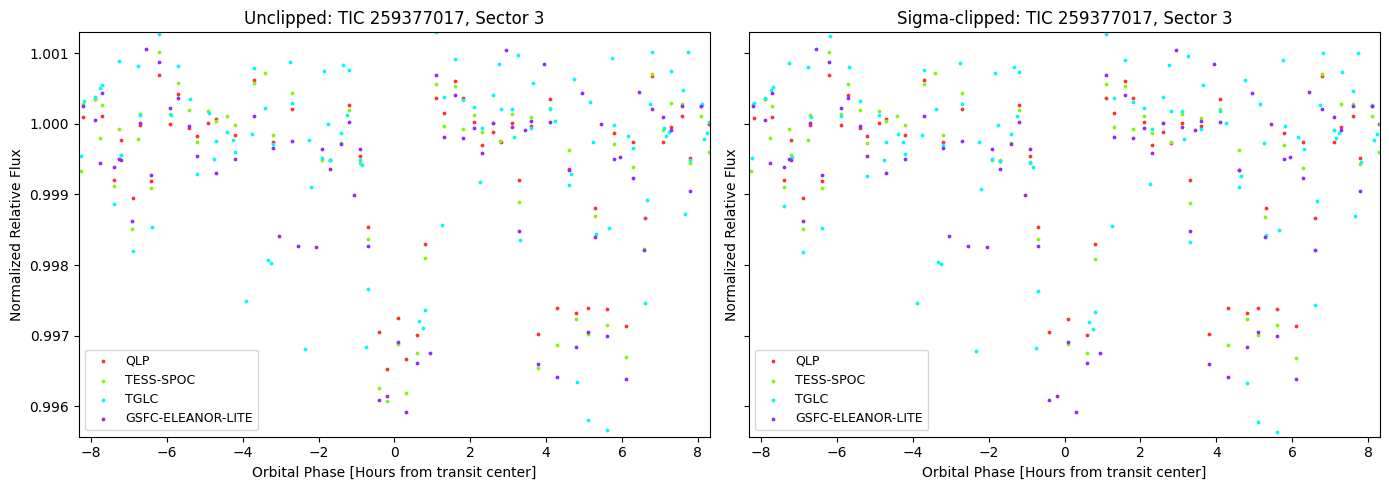

[LEO-Vetter] Running QLP for TIC 259377017, sector 3
[plot_modshift_NEMESIS] finite cadences kept: 857/857
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] QLP: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S3/TIC_259377017_S0003_QLP_LEOVetter_Report.png
[LEO-Vetter] Running TESS-SPOC for TIC 259377017, sector 3
[plot_modshift_NEMESIS] finite cadences kept: 837/837
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] TESS-SPOC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S3/TIC_259377017_S0003_TESS-SPOC_LEOVetter_Report.png
[LEO-Vetter] Running TGLC for TIC 259377017, sector 3
[plot_modshift_NEMESIS] finite cadences kept: 1077/1077
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
259377017.1: failed trapezoid model fit
259377017.1: failed left trapezoid fit
259377017.1: failed right trapezoid fit
259377017.1: failed transit model fit
Running SWEET test...
Getting odd-even metrics...
259377017.1: failed odd/even trapezoid fit
259377017.1: failed odd/even transit fit
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/individual.py:112: RuntimeWarning: invalid value encountered in sqrt
  tlc.metrics["CHI"] = tlc.metrics["MES"] / np.sqrt(chi2 / (tlc.N_transit - 1))
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/parameters.py:98: RuntimeWarning: invalid value encountered in sqrt
  RpRs, RpRs_err = np.sqrt(tlc.metrics["dep"]), np.nan


[LEO-Vetter] TGLC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S3/TIC_259377017_S0003_TGLC_LEOVetter_Report.png
[LEO-Vetter] Running GSFC-ELEANOR-LITE for TIC 259377017, sector 3
[plot_modshift_NEMESIS] finite cadences kept: 789/789
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] GSFC-ELEANOR-LITE: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S3/TIC_259377017_S0003_GSFC-ELEANOR-LITE_LEOVetter_Report.png

target_to_lightcurve_workflow took: 1.7 s



In [16]:
sector_results = target_to_lightcurve_workflow_V3(
    target=target, pipelines=pipelines, target_Sector=None,
    DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    save_results=True
)



In [17]:
sector_results.keys()

dict_keys(['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE'])

In [18]:
sector_results['GSFC-ELEANOR-LITE'].keys()

dict_keys(['product', 'raw', 'standardized', 'standardized_masked', 'tic_id', 'sector', 'pipeline', 'n_raw', 'n_standardized', 'n_masked', 'status', 'error', 'leo_vetter_metrics', 'leo_vetter_vetted'])

In [19]:
(sector_results['GSFC-ELEANOR-LITE']['leo_vetter_vetted'])

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn,LEOVetter_tic,LEOVetter_planetno,LEOVetter_per,LEOVetter_epo,LEOVetter_dur,LEOVetter_qtran,LEOVetter_N_transit,LEOVetter_n_in,LEOVetter_n_before,LEOVetter_n_after,LEOVetter_zpt,LEOVetter_dep,LEOVetter_sig_w,LEOVetter_sig_r,LEOVetter_err,LEOVetter_MES,LEOVetter_SHP,LEOVetter_line_chisqr,LEOVetter_line_aic,LEOVetter_trap_chisqr,LEOVetter_trap_aic,LEOVetter_trap_per,LEOVetter_trap_per_err,LEOVetter_trap_epo,LEOVetter_trap_epo_err,LEOVetter_trap_dep,LEOVetter_trap_dep_err,LEOVetter_trap_qtran,LEOVetter_trap_qtran_err,LEOVetter_trap_qin,LEOVetter_trap_qin_err,LEOVetter_trap_zpt,LEOVetter_trap_zpt_err,LEOVetter_trap_qtran_left,LEOVetter_trap_qtran_err_left,LEOVetter_trap_qtran_right,LEOVetter_trap_qtran_err_right,LEOVetter_transit_u1,LEOVetter_transit_u2,LEOVetter_transit_chisqr,LEOVetter_transit_aic,LEOVetter_transit_per,LEOVetter_transit_per_err,LEOVetter_transit_epo,LEOVetter_transit_epo_err,LEOVetter_transit_RpRs,LEOVetter_transit_RpRs_err,LEOVetter_transit_aRs,LEOVetter_transit_aRs_err,LEOVetter_transit_b,LEOVetter_transit_b_err,LEOVetter_transit_zpt,LEOVetter_transit_zpt_err,LEOVetter_sine_sig,LEOVetter_sine_amp,LEOVetter_odd_dep,LEOVetter_odd_dep_err,LEOVetter_even_dep,LEOVetter_even_dep_err,LEOVetter_sig_dep,LEOVetter_trap_odd_dep,LEOVetter_trap_odd_dep_err,LEOVetter_trap_even_dep,LEOVetter_trap_even_dep_err,LEOVetter_trap_odd_epo,LEOVetter_trap_odd_epo_err,LEOVetter_trap_even_epo,LEOVetter_trap_even_epo_err,LEOVetter_trap_sig_dep,LEOVetter_trap_sig_epo,LEOVetter_transit_odd_RpRs,LEOVetter_transit_odd_RpRs_err,LEOVetter_transit_even_RpRs,LEOVetter_transit_even_RpRs_err,LEOVetter_transit_odd_epo,LEOVetter_transit_odd_epo_err,LEOVetter_transit_even_epo,LEOVetter_transit_even_epo_err,LEOVetter_transit_sig_dep,LEOVetter_transit_sig_epo,LEOVetter_N_gap_0.5,LEOVetter_N_gap_1.0,LEOVetter_N_gap_1.5,LEOVetter_N_gap_2.0,LEOVetter_CHI,LEOVetter_med_chases,LEOVetter_mean_chases,LEOVetter_max_SES,LEOVetter_DMM,LEOVetter_new_N_transit,LEOVetter_new_MES,LEOVetter_FA1,LEOVetter_FA2,LEOVetter_phs_pri,LEOVetter_phs_sec,LEOVetter_phs_ter,LEOVetter_phs_pos,LEOVetter_sig_pri,LEOVetter_sig_sec,LEOVetter_sig_ter,LEOVetter_sig_pos,LEOVe

# Finally, we also want to eventually use every available TESS sector for a given cadence (It's complicated to compare different cadences to each other, so it's best to stick to the same cadence across sectors)

In [72]:
"""
leovetter_integration_v4.py

Drop-in additions to Madeline's TESS HLSP comparison pipeline.

New public API
--------------
get_available_sectors              Query MAST for all HLSP sectors at a given
                                   cadence for a TIC target.

target_to_lightcurve_workflow_V4   V3 + multi-sector support.  Accepts
                                   target_Sector as int | None | "all" |
                                   List[int].  Light curves are concatenated
                                   across sectors per pipeline before
                                   phase-folding and LEO-Vetter.

Unchanged from V3
-----------------
_standardized_to_nemesis_lc
Apply_LEOVetter

Dependencies assumed in scope
------------------------------
lk                                 lightkurve / lksearch
plot_modshift_NEMESIS              NEMESIS pipeline
get_qld                            NEMESIS pipeline
collect_lightcurves_for_target     standardizing_data.py
save_pipeline_results              standardizing_data_caching.py
load_pipeline_results              standardizing_data_caching.py
_get_colors                        standardizing_data.py
plot_phasefolded                   phasefold.py
sigma_clip                         astropy.stats
pipeline_colors                    defined at call site
"""
from __future__ import annotations

import os
import time as clock
from typing import Any, Dict, List, Literal, Optional, Union

import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip


# ---------------------------------------------------------------------------
# Helper: MAST sector discovery
# ---------------------------------------------------------------------------

def get_available_sectors(
    tic_id: Union[int, str],
    exptime: str = "1800",
    pipelines: Optional[List[str]] = None,
    radius: Union[float, Any] = 0.0001,
    *,
    max_sector: Optional[int] = 26,
    verbose: bool = True,
) -> List[int]:
    """
    Query MAST for all TESS sectors in which a given TIC target has a
    published HLSP light curve at the requested cadence.

    Parameters
    ----------
    tic_id : int or str
        TIC identifier.
    exptime : str, optional
        Exposure-time string passed to ``lk.TESSSearch``.  Use ``"1800"``
        for 30-minute FFI cadence (default), ``"120"`` for 2-minute.
    pipelines : list of str or None, optional
        If provided, only sectors that have at least one product from any of
        the listed pipelines are returned.  None → all HLSP pipelines.
    radius : float or astropy Quantity, optional
        Cone-search radius.  Default 0.0001 deg (point-source search).
    max_sector : int or None, optional
        Discard any sector number greater than this value.  Default 26
        (TESS primary mission).  Pass None to return all sectors.
    verbose : bool, optional
        Print discovered sector list.  Default True.

    Returns
    -------
    sectors : list of int
        Sorted unique sector numbers.  Empty list on any failure.

    Examples
    --------
    >>> get_available_sectors(259377017, exptime="1800",
    ...     pipelines=["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"])
    [get_available_sectors] TIC 259377017: found sectors [3, 30, 57] at exptime='1800'
    [3, 30, 57]
    """
    import lksearch as _lk
    tic_str = str(int(float(str(tic_id).strip())))
    search_radius = float(radius) if isinstance(radius, (int, float, np.floating)) else radius

    try:
        search = _lk.TESSSearch(
            target=f"TIC {tic_str}",
            search_radius=search_radius,
            exptime=exptime,
            hlsp=True,
        )
        try:
            ts = search.timeseries
        except Exception:
            ts = search
        table = getattr(ts, "table", None)
    except Exception as exc:
        if verbose:
            print(f"[get_available_sectors] MAST query failed for TIC {tic_str}: {exc}")
        return []

    if table is None or len(table) == 0:
        if verbose:
            print(f"[get_available_sectors] No HLSP products for TIC {tic_str} "
                  f"at exptime={exptime!r}.")
        return []

    if not isinstance(table, pd.DataFrame):
        try:
            table = table.to_pandas()
        except Exception:
            table = pd.DataFrame(table)

    if "mission" in table.columns:
        table = table[table["mission"].astype(str).str.upper().eq("HLSP")].copy()

    if pipelines is not None and "pipeline" in table.columns:
        table = table[table["pipeline"].astype(str).isin(pipelines)].copy()

    if len(table) == 0:
        if verbose:
            print(f"[get_available_sectors] No rows after pipeline filter for TIC {tic_str}.")
        return []

    sector_col: Optional[str] = None
    for c in ("sector", "sequence_number"):
        if c in table.columns:
            sector_col = c
            break

    if sector_col is None:
        if verbose:
            print(f"[get_available_sectors] No sector column found. "
                  f"Columns: {list(table.columns)}")
        return []

    raw_vals = table[sector_col].dropna().astype(str).str.strip()
    sectors: List[int] = sorted({
        int(float(v)) for v in raw_vals
        if v.lower() not in {"nan", "none", ""}
    })

    if max_sector is not None:
        sectors = [s for s in sectors if s <= max_sector]

    if verbose:
        print(f"[get_available_sectors] TIC {tic_str}: found sectors {sectors} "
              f"at exptime={exptime!r}"
              + (f", max_sector={max_sector}" if max_sector is not None else "")
              + (f", pipelines={pipelines}" if pipelines else ""))

    return sectors


# ---------------------------------------------------------------------------
# Helper: standardized schema → NEMESIS-style (unchanged from V3)
# ---------------------------------------------------------------------------

def _standardized_to_nemesis_lc(std_df: pd.DataFrame) -> pd.DataFrame:
    """
    Map a standardized light-curve DataFrame to NEMESIS-style column names
    required by ``plot_modshift_NEMESIS`` / ``TCELightCurve``.

    Normalization: flux_corr and err are divided by nanmedian(flux_corr).
    Error fallback: flux_corr_err → MAD scatter of flux_corr if all-NaN.

    Parameters
    ----------
    std_df : pd.DataFrame
        Standardized DataFrame with columns: time, flux_corr, flux_corr_err.

    Returns
    -------
    pd.DataFrame
        Columns: Time, SAP Flux, Detrended Flux, Detrended Error.
        Rows where Time or Detrended Flux are non-finite are dropped.

    Examples
    --------
    >>> lc_nms = _standardized_to_nemesis_lc(results["QLP"]["standardized_masked"])
    >>> list(lc_nms.columns)
    ['Time', 'SAP Flux', 'Detrended Flux', 'Detrended Error']
    """
    sap = std_df["flux_corr"].to_numpy(dtype=float)

    err = std_df["flux_corr_err"].to_numpy(dtype=float)
    if not np.any(np.isfinite(err)):
        from astropy.stats import mad_std
        corr_vals = std_df["flux_corr"].to_numpy(dtype=float)
        scatter = (mad_std(corr_vals[np.isfinite(corr_vals)])
                   if np.any(np.isfinite(corr_vals)) else 1.0)
        err = np.full(len(std_df), scatter, dtype=float)

    median = np.nanmedian(std_df["flux_corr"].to_numpy(dtype=float))
    corr_norm = std_df["flux_corr"].to_numpy(dtype=float) / median
    err_norm  = err / median

    lc_nms = pd.DataFrame({
        "Time":            std_df["time"].to_numpy(dtype=float),
        "SAP Flux":        sap / np.nanmedian(sap),
        "Detrended Flux":  corr_norm,
        "Detrended Error": err_norm,
    }, index=std_df.index)

    valid = np.isfinite(lc_nms["Time"]) & np.isfinite(lc_nms["Detrended Flux"])
    return lc_nms.loc[valid].reset_index(drop=True)


# ---------------------------------------------------------------------------
# Apply_LEOVetter (unchanged from V3)
# ---------------------------------------------------------------------------

def Apply_LEOVetter(
    ID: Union[int, str],
    target: Union[pd.DataFrame, pd.Series],
    sector: Union[int, List[int]],
    LC_df: pd.DataFrame,
    pipeline: str,
    savepath: str,
    *,
    corrected_T0: Optional[float] = None,
    verbose: bool = False,
) -> Optional[pd.DataFrame]:
    """
    Produce a LEO-Vetter modshift report for one pipeline's light curve.

    Parameters
    ----------
    ID : int or str
        TIC identifier.
    target : pd.DataFrame or pd.Series
        Single target row.  Must carry orbital parameters and get_qld columns.
    sector : int or list of int
        Sector(s) processed; used only for the output filename.
    LC_df : pd.DataFrame
        NEMESIS-style LC from ``_standardized_to_nemesis_lc``.
    pipeline : str
        Pipeline name; used for filename.
    savepath : str
        Directory for the PNG report.
    corrected_T0 : float or None, optional
        Per-pipeline corrected epoch (BTJD).  Falls back to catalog value.
    verbose : bool, optional
        Passed to ``plot_modshift_NEMESIS``.

    Returns
    -------
    metrics : pd.DataFrame or None

    Examples
    --------
    >>> metrics = Apply_LEOVetter(ID=259377017, target=target,
    ...     sector=[3, 30], LC_df=lc_nms, pipeline="QLP",
    ...     savepath="/data/results/TIC259377017_S3to30",
    ...     corrected_T0=1385.446)
    """
    if isinstance(target, pd.Series):
        star = target.to_frame().T.reset_index(drop=True)
    else:
        star = target.copy().reset_index(drop=True)

    P   = float(star["Orbital Period (days) Value"].iloc[0])
    T0  = float(corrected_T0 if corrected_T0 is not None
                else star["Orbital Epoch Value"].iloc[0])
    Dur = float(star["Transit Duration (hours) Value"].iloc[0])
    dur_days = (Dur * u.hour).to(u.day).value

    # Build a sector tag that works for both single and multi-sector
    if isinstance(sector, (list, tuple)):
        s_sorted = sorted(int(s) for s in sector)
        sector_tag = (f"S{s_sorted[0]:04d}" if len(s_sorted) == 1
                      else f"S{s_sorted[0]:04d}to{s_sorted[-1]:04d}")
    else:
        sector_tag = f"S{int(sector):04d}"

    os.makedirs(savepath, exist_ok=True)
    savefilename = os.path.join(
        savepath, f"TIC_{ID}_{sector_tag}_{pipeline}_LEOVetter_Report.png"
    )

    try:
        metrics = plot_modshift_NEMESIS(
            ID=ID, star=star, LC_df=LC_df,
            period=P, dur=dur_days, T0=T0,
            save_file=savefilename, verbose=verbose,
        )
        if verbose:
            print(f"[LEO-Vetter] {pipeline}: report saved → {savefilename}")
        return metrics
    except Exception as exc:
        print(f"[LEO-Vetter] {pipeline} failed: {exc}")
        return None


# ---------------------------------------------------------------------------
# target_to_lightcurve_workflow_V4
# ---------------------------------------------------------------------------

def target_to_lightcurve_workflow_V4(
    target: Union[pd.Series, pd.DataFrame],
    pipelines: List[str],
    target_Sector: Union[int, None, Literal["all"], List[int]],
    DEFAULT_RADIUS: Any,
    DEFAULT_CADENCE: str,
    DEFAULT_DOWNLOADPATH: str,
    *,
    save_results: bool = True,
    results_savepath: Optional[str] = None,
    force_redownload: bool = False,
    run_leovetter: bool = True,
    leovetter_savepath: Optional[str] = None,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Download, standardize, concatenate across sectors, phase-fold, and vet
    TESS HLSP light curves across multiple pipelines for a single target.

    Extends V3 with multi-sector support.  When multiple sectors are
    requested, standardized DataFrames from each sector are concatenated
    per pipeline (sorted by time) before phase-folding and LEO-Vetter.
    Per-sector Parquet results are still saved individually to disk; the
    concatenated result lives only in the returned dict.

    Sector selection via ``target_Sector``
    --------------------------------------
    int           Process that sector only  (identical to V3).
    None          Resolve earliest available sector via MAST query; process
                  only that one  (reproduces V3 None behavior).
    "all"         Discover every available sector via ``get_available_sectors``
                  and concatenate all of them.
    List[int]     Process exactly the listed sectors and concatenate.

    Parameters
    ----------
    target : pd.Series or single-row pd.DataFrame
        Target row.  Required keys: ``'TIC ID'``,
        ``'Orbital Period (days) Value'``, ``'Orbital Epoch Value'``,
        ``'Transit Depth Value'``, ``'Transit Duration (hours) Value'``,
        ``'Sectors'``, and any columns required by ``get_qld``.
    pipelines : list of str
        HLSP pipeline names, e.g.
        ``["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]``.
    target_Sector : int | None | "all" | list of int
        Sector selection (see above).
    DEFAULT_RADIUS : astropy Quantity or float
        Cone-search radius.
    DEFAULT_CADENCE : str
        Cadence/exptime string (e.g. ``"1800"`` or ``"30 minute"``).
    DEFAULT_DOWNLOADPATH : str
        Root directory for raw FITS downloads and FITS cache index.
    save_results : bool, optional
        Persist per-sector standardized DataFrames to Parquet after a live
        download.  Default True.
    results_savepath : str or None, optional
        Root for Parquet outputs.  Defaults to
        ``DEFAULT_DOWNLOADPATH/saved_results``.
    force_redownload : bool, optional
        Skip all caches.  Default False.
    run_leovetter : bool, optional
        Run LEO-Vetter on each successful pipeline after plotting.
        Default True.
    leovetter_savepath : str or None, optional
        Directory for LEO-Vetter PNGs.  Defaults to
        ``{results_savepath}/TIC{ID}_{sector_tag}``.
    verbose : bool, optional
        Print progress messages.  Default True.

    Returns
    -------
    combined_results : dict
        Pipeline-keyed dict.  Same structure as V3's ``sector_results``
        with ``standardized`` and ``standardized_masked`` containing
        concatenated DataFrames across all sectors.  Additional keys:

        - ``"sectors"`` : list of int — sectors that contributed data.
        - ``"leo_vetter_metrics"`` : pd.DataFrame or None
        - ``"leo_vetter_vetted"``  : pd.DataFrame or None

    Notes
    -----
    - Sectors that fail to download for a given pipeline are skipped for
      that pipeline; the pipeline can still appear in combined_results if
      at least one sector succeeded.
    - ``corrected_T0`` for phase-folding and LEO-Vetter is derived from the
      concatenated LC's global time minimum, so the epoch correction spans
      the full multi-sector baseline.
    - ``n_raw``, ``n_standardized``, ``n_masked`` in combined_results are
      the sums across all contributing sectors.

    Examples
    --------
    >>> target = nearby_TOI_MD_df.loc[
    ...     nearby_TOI_MD_df["TIC ID"].astype(int) == 259377017
    ... ].reset_index(drop=True).iloc[0]
    >>> pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
    >>> pipeline_colors = _get_colors(len(pipelines))

    # All available 30-min sectors, concatenated
    >>> results = target_to_lightcurve_workflow_V4(
    ...     target=target, pipelines=pipelines,
    ...     target_Sector="all",
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS,
    ...     DEFAULT_CADENCE="1800",
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    >>> results["QLP"]["standardized"].shape
    (N_total_cadences_across_all_sectors, n_columns)
    >>> results["QLP"]["sectors"]
    [3, 30, 57]
    """
    t_start = clock.time()

    # ------------------------------------------------------------------ #
    #  Unpack target metadata                                             #
    # ------------------------------------------------------------------ #
    ID         = target["TIC ID"].item()
    target_P   = target["Orbital Period (days) Value"].item()
    target_T0  = target["Orbital Epoch Value"].item()
    target_Dur = target["Transit Duration (hours) Value"].item()
    target_Dep = target['Transit Depth Value'].item()/1e6

    if results_savepath is None:
        results_savepath = os.path.join(DEFAULT_DOWNLOADPATH, "saved_results")

    # ------------------------------------------------------------------ #
    #  Resolve sector list                                                #
    # ------------------------------------------------------------------ #
    if isinstance(target_Sector, list):
        sectors = sorted(int(s) for s in target_Sector)
        if verbose:
            print(f"[V4] TIC {ID}: explicit sector list → {sectors}")

    elif target_Sector == "all":
        sectors = get_available_sectors(
            tic_id=ID,
            exptime=DEFAULT_CADENCE,
            pipelines=pipelines,
            radius=DEFAULT_RADIUS,
            verbose=verbose,
        )
        if not sectors:
            print(f"[V4] TIC {ID}: no sectors found via MAST — aborting.")
            return {}

    elif target_Sector is None:
        # Reproduce V3 behavior: earliest available sector
        _all = get_available_sectors(
            tic_id=ID,
            exptime=DEFAULT_CADENCE,
            pipelines=pipelines,
            radius=DEFAULT_RADIUS,
            verbose=verbose,
        )
        if _all:
            sectors = [_all[0]]
            if verbose:
                print(f"[V4] TIC {ID}: target_Sector=None → earliest sector {sectors[0]}")
        else:
            # Let collect_lightcurves_for_target resolve from target["Sectors"]
            sectors = [None]
            if verbose:
                print(f"[V4] TIC {ID}: MAST query empty; delegating sector=None downstream.")

    else:
        sectors = [int(target_Sector)]

    # Build a human-readable sector tag for paths / filenames
    valid_sectors = [s for s in sectors if s is not None]
    if len(valid_sectors) == 0:
        sector_tag = "Sauto"
    elif len(valid_sectors) == 1:
        sector_tag = f"S{valid_sectors[0]:04d}"
    else:
        sector_tag = f"S{min(valid_sectors):04d}to{max(valid_sectors):04d}"

    if leovetter_savepath is None:
        leovetter_savepath = os.path.join(
            results_savepath, f"TIC{ID}_{sector_tag}"
        )

    # ------------------------------------------------------------------ #
    #  Per-sector download / cache loop                                   #
    #  Accumulate standardized DataFrames per pipeline across sectors     #
    # ------------------------------------------------------------------ #
    # Structure: pipeline → {"std": [df, ...], "std_masked": [df, ...],
    #                         "sectors_ok": [int, ...],
    #                         "n_raw": int, "n_std": int, "n_masked": int,
    #                         "last_error": str or None}
    accum: Dict[str, Dict[str, Any]] = {
        p: {"std": [], "std_masked": [], "sectors_ok": [],
            "n_raw": 0, "n_std": 0, "n_masked": 0, "last_error": None}
        for p in pipelines
    }

    for sector in sectors:
        if verbose:
            print(f"\n[V4] ── Sector {sector} ──────────────────────────────────")

        sector_results = None

        # Try loading from Parquet cache first (only for integer sectors)
        if not force_redownload and sector is not None:
            try:
                sector_results = load_pipeline_results(
                    savepath=results_savepath,
                    tic_id=ID,
                    sector=sector,
                )
                if verbose:
                    print(f"[V4] Cache hit: TIC {ID}, sector {sector}")
            except FileNotFoundError:
                if verbose:
                    print(f"[V4] Cache miss: TIC {ID}, sector {sector} — downloading.")

        if sector_results is None:
            try:
                sector_results = collect_lightcurves_for_target(
                    tic_id=ID,
                    sector=sector,
                    pipelines=pipelines,
                    downloadpath=DEFAULT_DOWNLOADPATH,
                    radius=DEFAULT_RADIUS,
                    exptime=DEFAULT_CADENCE,
                    apply_quality_mask=True,
                    verbose=verbose,
                )
            except Exception as exc:
                print(f"[V4] collect_lightcurves_for_target failed for sector "
                      f"{sector}: {exc}")
                for p in pipelines:
                    accum[p]["last_error"] = str(exc)
                continue

            if save_results and sector is not None:
                try:
                    outdir = save_pipeline_results(
                        results=sector_results,
                        savepath=results_savepath,
                        tic_id=ID,
                        sector=sector,
                        overwrite=True,
                    )
                    if verbose:
                        print(f"[V4] Saved sector {sector} → {outdir}")
                except Exception as exc:
                    print(f"[V4] Warning: could not save sector {sector}: {exc}")

        # Accumulate per pipeline
        for p in pipelines:
            info = sector_results.get(p, {})
            if info.get("status") != "ok":
                accum[p]["last_error"] = info.get("error", "unknown")
                continue

            df_std = info.get("standardized")
            if df_std is None or df_std.empty:
                continue

            # Normalize per-sector before accumulating.  Applied here rather
            # than relying solely on collect_lightcurves_for_target so that
            # Parquet-cached data saved before normalization was introduced
            # is also corrected transparently.
            df_std = normalize_standardized_lc(df_std)

            # Re-derive the quality mask from the normalized df_std.
            # _apply_quality_mask enforces quality == 0 AND quality2 == 0
            # (dual-flag for TGLC; quality2 NaN passes for all others)
            # and raises ValueError if any flagged rows survive.
            df_msk = _apply_quality_mask(df_std, pipeline=p)

            accum[p]["std"].append(df_std)
            accum[p]["n_raw"] += int(info.get("n_raw") or 0)
            accum[p]["n_std"] += int(info.get("n_standardized") or len(df_std))
            accum[p]["sectors_ok"].append(sector if sector is not None else -1)

            if not df_msk.empty:
                accum[p]["std_masked"].append(df_msk)
                accum[p]["n_masked"] += len(df_msk)

    # ------------------------------------------------------------------ #
    #  Concatenate per pipeline, sort by time                             #
    # ------------------------------------------------------------------ #
    combined_results: Dict[str, Any] = {}

    for p in pipelines:
        a = accum[p]
        if not a["std"]:
            # No data at all for this pipeline across any sector
            combined_results[p] = {
                "product": None, "raw": None,
                "standardized": None, "standardized_masked": None,
                "tic_id": ID, "sector": sectors, "sectors": [],
                "pipeline": p,
                "n_raw": 0, "n_standardized": 0, "n_masked": 0,
                "status": "error",
                "error": a["last_error"] or "no data across requested sectors",
                "leo_vetter_metrics": None, "leo_vetter_vetted": None,
            }
            continue

        std_concat = (
            pd.concat(a["std"], ignore_index=True)
            .sort_values("time").reset_index(drop=True)
        )
        msk_concat = None
        if a["std_masked"]:
            msk_concat = (
                pd.concat(a["std_masked"], ignore_index=True)
                .sort_values("time").reset_index(drop=True)
            )

        combined_results[p] = {
            "product": None,
            "raw": None,          # raw per-sector not concatenated; load from Parquet if needed
            "standardized":        std_concat,
            "standardized_masked": msk_concat,
            "tic_id": ID,
            "sector":  a["sectors_ok"],   # list of contributing sector ints
            "sectors": a["sectors_ok"],
            "pipeline": p,
            "n_raw":          a["n_raw"],
            "n_standardized": a["n_std"],
            "n_masked":       a["n_masked"],
            "status": "ok",
            "error": None,
            "leo_vetter_metrics": None,
            "leo_vetter_vetted":  None,
        }

    if verbose:
        for p in pipelines:
            st = combined_results[p]["status"]
            ns = combined_results[p]["n_standardized"]
            secs = combined_results[p]["sectors"]
            print(f"[V4] {p}: status={st}, cadences={ns}, sectors={secs}")

    # ------------------------------------------------------------------ #
    #  Phase-fold loop on concatenated light curves                       #
    # ------------------------------------------------------------------ #
    corrected_epochs: Dict[str, Optional[float]] = {}
    pipeline_data:    Dict[str, Optional[Dict[str, Any]]] = {}
    all_flux_unclipped: List[np.ndarray] = []
    all_flux_clipped:   List[np.ndarray] = []

    for p in pipelines:
        info = combined_results[p]
        if info["status"] != "ok":
            corrected_epochs[p] = None
            pipeline_data[p]    = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]
        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            pipeline_data[p]    = None
            continue

        flux   = lc_to_plot["flux_corr"].to_numpy()
        t_min  = lc_to_plot["time"].min()
        n_first = int(np.ceil((t_min - target_T0) / target_P))
        corrected_epochs[p] = target_T0 + n_first * target_P

        flux_norm = flux / np.nanmedian(flux)
        clipped   = sigma_clip(
            flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5
        )
        good     = ~clipped.mask
        lc_clean = lc_to_plot.iloc[good].reset_index(drop=True)

        if verbose:
            print(f"[V4] {p}: {len(flux_norm)} cadences total, "
                  f"{np.sum(clipped.mask)} removed by sigma-clip")

        pipeline_data[p] = {
            "lc":       lc_to_plot,
            "lc_clean": lc_clean,
            "T0":       corrected_epochs[p],
        }
        all_flux_unclipped.append(flux_norm)
        all_flux_clipped.append(flux_norm[good])

    # ------------------------------------------------------------------ #
    #  Phase-fold comparison plot                                         #
    # ------------------------------------------------------------------ #
    from astropy.stats import mad_std as _mad_std

    # Y-limits: transit depth + OOT scatter
    # (1 - depth) - 3σ  to  1 + 3σ  where σ = MAD of sigma-clipped flux.
    # Physically motivated: transit is always fully framed; padding scales
    # with per-target noise rather than the flux range of outliers.
    if all_flux_clipped:
        af_clipped = np.concatenate(all_flux_clipped)
        finite_clipped = af_clipped[np.isfinite(af_clipped)]
        scatter = _mad_std(finite_clipped) if finite_clipped.size > 0 else 0.01
    else:
        scatter = 0.01  # fallback if no pipeline succeeded

    y_min = (1.0 - target_Dep) - 10.0 * scatter
    y_max =  1.0               + 10.0 * scatter
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    for i, p in enumerate(pipelines):
        if pipeline_data.get(p) is None:
            continue
        pdata = pipeline_data[p]
        C = pipeline_colors[i]
        plot_phasefolded(ax=axes[0], target=target, lc=pdata["lc"],
                         color=C, label=p, T0=pdata["T0"])
        plot_phasefolded(ax=axes[1], target=target, lc=pdata["lc_clean"],
                         color=C, label=p, T0=pdata["T0"])

    if all_flux_unclipped:
        axes[0].set_ylim(y_min, y_max)
    if all_flux_clipped:
        axes[1].set_ylim(y_min, y_max)

    for ax in axes:
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, {sector_tag}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, {sector_tag}")
    plt.tight_layout()

    os.makedirs(leovetter_savepath, exist_ok=True)
    phasefold_figpath = os.path.join(
        leovetter_savepath,
        f"TIC_{ID}_{sector_tag}_phasefold_comparison.png",
    )
    fig.savefig(phasefold_figpath, bbox_inches="tight", dpi=150)
    if verbose:
        print(f"[V4] Phase-fold figure saved → {phasefold_figpath}")
    plt.show()

    # ------------------------------------------------------------------ #
    #  LEO-Vetter on concatenated light curves                            #
    # ------------------------------------------------------------------ #
    if run_leovetter:
        target_df = (
            target.to_frame().T.reset_index(drop=True)
            if isinstance(target, pd.Series)
            else target.reset_index(drop=True)
        )

        for p in pipelines:
            lc_std = combined_results[p].get("standardized_masked")
            if lc_std is None or lc_std.empty:
                lc_std = combined_results[p].get("standardized")
            if lc_std is None or lc_std.empty:
                if verbose:
                    print(f"[LEO-Vetter] {p}: no valid concatenated LC — skipping.")
                continue

            lv_T0  = corrected_epochs.get(p) or target_T0
            lc_nms = _standardized_to_nemesis_lc(lc_std)
            sectors_used = combined_results[p].get("sectors", valid_sectors)

            if verbose:
                print(f"[LEO-Vetter] Running {p} for TIC {ID}, {sector_tag}")

            metrics = Apply_LEOVetter(
                ID=ID,
                target=target,
                sector=sectors_used,
                LC_df=lc_nms,
                pipeline=p,
                savepath=leovetter_savepath,
                corrected_T0=lv_T0,
                verbose=verbose,
            )

            if metrics is not None:
                combined_results[p]["leo_vetter_metrics"] = metrics
                combined_results[p]["leo_vetter_vetted"]  = pd.concat(
                    [target_df, metrics.add_prefix("LEOVetter_")],
                    axis=1,
                ).reset_index(drop=True)

    # ------------------------------------------------------------------ #
    #  Timing                                                             #
    # ------------------------------------------------------------------ #
    if verbose:
        elapsed = clock.time() - t_start
        print(f"\n{'='*40}")
        print(f"target_to_lightcurve_workflow_V4 took: {elapsed:.1f} s")
        print(f"{'='*40}\n")

    return combined_results

[get_available_sectors] TIC 259377017: found sectors [3, 4, 5] at exptime='30 minute', max_sector=26, pipelines=['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE']
[V4] TIC 259377017: target_Sector=None → earliest sector 3

[V4] ── Sector 3 ──────────────────────────────────
[V4] Cache hit: TIC 259377017, sector 3
[V4] QLP: status=ok, cadences=1304, sectors=[3]
[V4] TESS-SPOC: status=ok, cadences=1312, sectors=[3]
[V4] TGLC: status=ok, cadences=1288, sectors=[3]
[V4] GSFC-ELEANOR-LITE: status=ok, cadences=1288, sectors=[3]
[V4] QLP: 857 cadences total, 2 removed by sigma-clip
[V4] TESS-SPOC: 857 cadences total, 24 removed by sigma-clip
[V4] TGLC: 908 cadences total, 0 removed by sigma-clip
[V4] GSFC-ELEANOR-LITE: 789 cadences total, 2 removed by sigma-clip


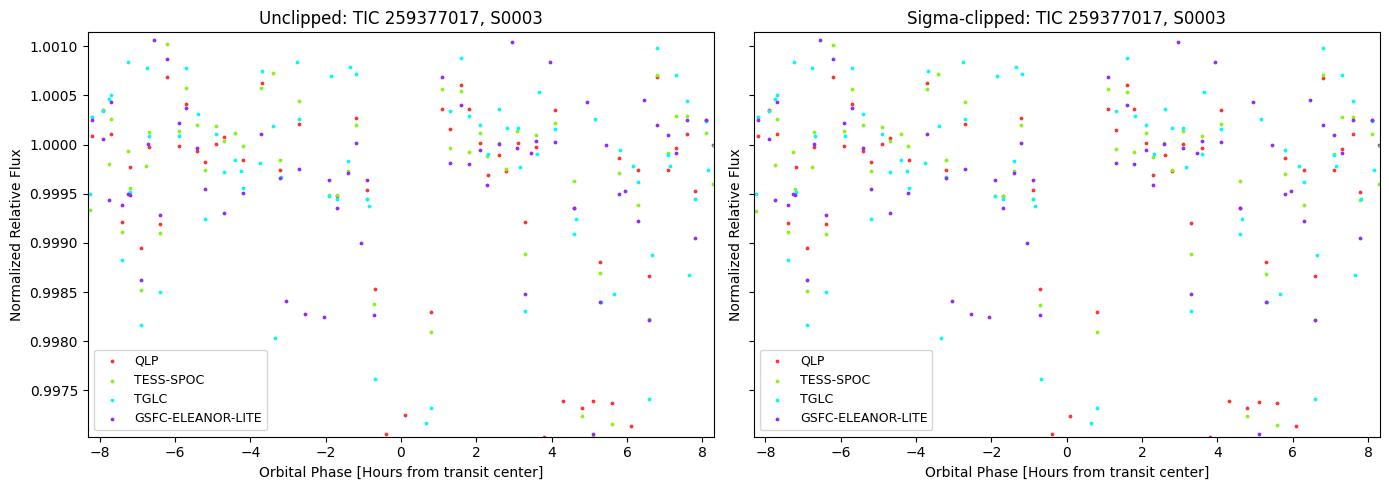

[LEO-Vetter] Running QLP for TIC 259377017, S0003
[plot_modshift_NEMESIS] finite cadences kept: 857/857
Estimating SES and MES time series...


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!
[LEO-Vetter] QLP: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003/TIC_259377017_S0003_QLP_LEOVetter_Report.png
[LEO-Vetter] Running TESS-SPOC for TIC 259377017, S0003
[plot_modshift_NEMESIS] finite cadences kept: 837/837
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] TESS-SPOC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003/TIC_259377017_S0003_TESS-SPOC_LEOVetter_Report.png
[LEO-Vetter] Running TGLC for TIC 259377017, S0003
[plot_modshift_NEMESIS] finite cadences kept: 908/908
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] TGLC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003/TIC_259377017_S0003_TGLC_LEOVetter_Report.png
[LEO-Vetter] Running GSFC-ELEANOR-LITE for TIC 259377017, S0003
[plot_modshift_NEMESIS] finite cadences kept: 789/789
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] GSFC-ELEANOR-LITE: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003/TIC_259377017_S0003_GSFC-ELEANOR-LITE_LEOVetter_Report.png

target_to_lightcurve_workflow_V4 took: 2.6 s



In [58]:
sector_results = target_to_lightcurve_workflow_V4(
    target=target, pipelines=pipelines, target_Sector=None,
    DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    save_results=True
)



# now using all available sectors

[get_available_sectors] TIC 259377017: found sectors [3, 4, 5] at exptime='30 minute', max_sector=26, pipelines=['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE']

[V4] ── Sector 3 ──────────────────────────────────
[V4] Cache hit: TIC 259377017, sector 3

[V4] ── Sector 4 ──────────────────────────────────
[V4] Cache hit: TIC 259377017, sector 4

[V4] ── Sector 5 ──────────────────────────────────
[V4] Cache hit: TIC 259377017, sector 5
[V4] QLP: status=ok, cadences=3560, sectors=[3, 4, 5]
[V4] TESS-SPOC: status=ok, cadences=3818, sectors=[3, 4, 5]
[V4] TGLC: status=ok, cadences=3544, sectors=[3, 4, 5]
[V4] GSFC-ELEANOR-LITE: status=ok, cadences=3544, sectors=[3, 4, 5]
[V4] QLP: 2223 cadences total, 91 removed by sigma-clip
[V4] TESS-SPOC: 3024 cadences total, 164 removed by sigma-clip
[V4] TGLC: 2963 cadences total, 16 removed by sigma-clip
[V4] GSFC-ELEANOR-LITE: 2672 cadences total, 38 removed by sigma-clip


[V4] Phase-fold figure saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003to0005/TIC_259377017_S0003to0005_phasefold_comparison.png


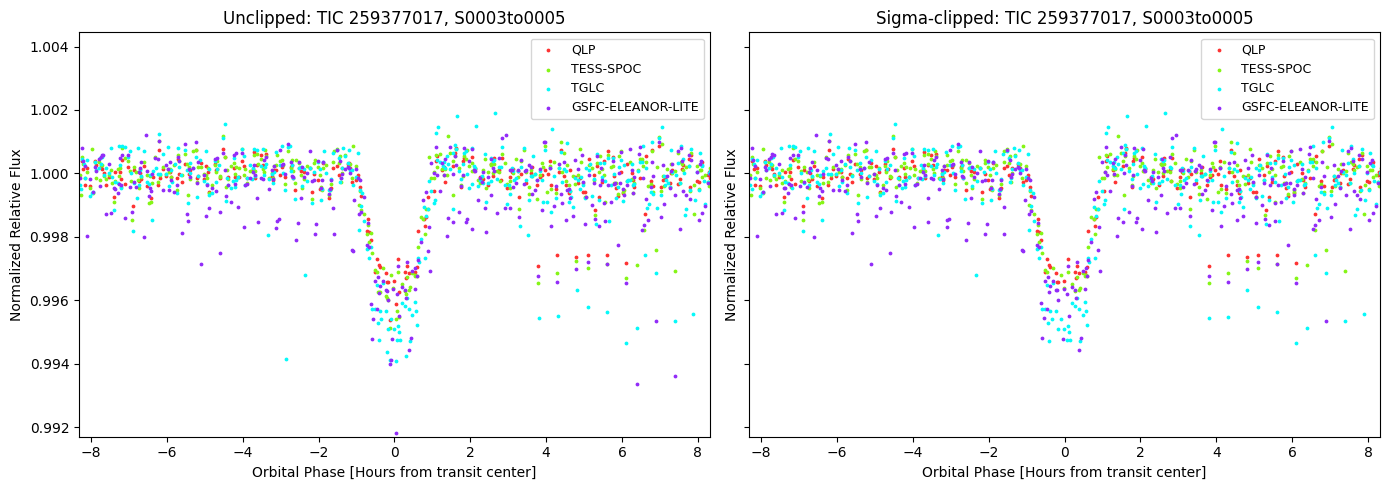

[LEO-Vetter] Running QLP for TIC 259377017, S0003to0005
[plot_modshift_NEMESIS] finite cadences kept: 2136/2136
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] QLP: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003to0005/TIC_259377017_S0003to0005_QLP_LEOVetter_Report.png
[LEO-Vetter] Running TESS-SPOC for TIC 259377017, S0003to0005
[plot_modshift_NEMESIS] finite cadences kept: 2872/2872
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] TESS-SPOC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003to0005/TIC_259377017_S0003to0005_TESS-SPOC_LEOVetter_Report.png
[LEO-Vetter] Running TGLC for TIC 259377017, S0003to0005
[plot_modshift_NEMESIS] finite cadences kept: 2963/2963
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] TGLC: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003to0005/TIC_259377017_S0003to0005_TGLC_LEOVetter_Report.png
[LEO-Vetter] Running GSFC-ELEANOR-LITE for TIC 259377017, S0003to0005
[plot_modshift_NEMESIS] finite cadences kept: 2672/2672
Estimating SES and MES time series...
Fitting linear, trapezoid, and transit models...
Running SWEET test...
Getting odd-even metrics...
Checking individual transit events...
Running modshift...
Estimating derived parameters...
Done!


/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/daxfeliz/opt/anaconda3/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))


[LEO-Vetter] GSFC-ELEANOR-LITE: report saved → /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results/TIC259377017_S0003to0005/TIC_259377017_S0003to0005_GSFC-ELEANOR-LITE_LEOVetter_Report.png

target_to_lightcurve_workflow_V4 took: 2.9 s



In [73]:

sector_results = target_to_lightcurve_workflow_V4(
    target=target, pipelines=pipelines, target_Sector='all',
    DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    save_results=True,
    force_redownload=False,# Set to True to overwrite saved .parquet files
)

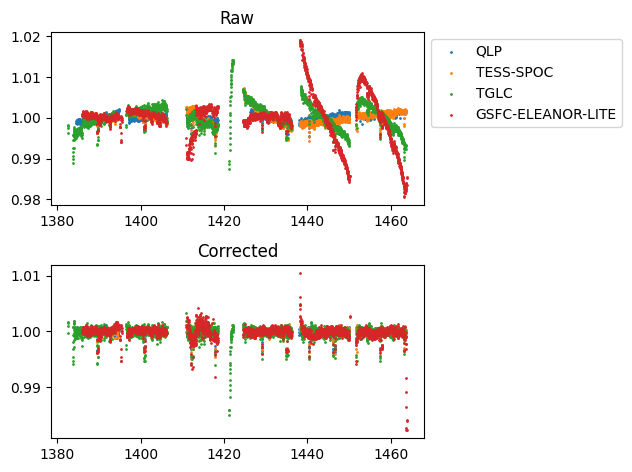

In [74]:
pipelines=['TGLC']
pipelines=["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]

fig =plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.set_title('Raw')
for p in pipelines:
    ax1.scatter(sector_results[p]['standardized_masked']['time'],
               sector_results[p]['standardized_masked']['flux_raw'],s=1,label=p)

    ax2.scatter(sector_results[p]['standardized_masked']['time'],
               sector_results[p]['standardized_masked']['flux_corr']/np.nanmedian(sector_results[p]['standardized_masked']['flux_corr']),s=1,label=p)
    
ax2.set_title('Corrected')
ax1.legend(loc='upper left',bbox_to_anchor=(1,1))    
fig.tight_layout(pad=1)
fig.savefig('tglc.png',bbox_inches='tight')
plt.show()